In [213]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
import matplotlib.pyplot as plt
from Bio.Data import CodonTable
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from statsmodels.stats.multitest import multipletests
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve, auc, accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from tqdm import tqdm

In [154]:
import warnings
warnings.filterwarnings("ignore")

In [342]:
def read_gene_expression(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_somatic_mutations(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_patient_metadata(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df


def handle_missing_data(df: pd.DataFrame,
                        subset_cols: list = None,
                        method: str = "drop") -> pd.DataFrame:

    if method == "drop":
        if subset_cols:
            return df.dropna(subset=subset_cols)
        return df.dropna()
    elif method == "fill":
        numeric = df.select_dtypes(include=[np.number]).columns
        df[numeric] = df[numeric].fillna(df[numeric].mean())
        return df
    else:
        raise ValueError("method must be 'drop' or 'fill'")

def kaplan_meier_survival(df: pd.DataFrame,
                          time_col: str = 'DSS.time',
                          event_col: str = 'DSS') -> KaplanMeierFitter:

    km_df = df[[time_col, event_col]].copy()
    km_df[time_col] = pd.to_numeric(km_df[time_col], errors='coerce')
    km_df[event_col] = pd.to_numeric(km_df[event_col], errors='coerce')
    km_df = handle_missing_data(km_df, subset_cols=[time_col, event_col], method="drop")
    if km_df.empty:
        raise ValueError("No data left for KM after cleaning")
    kmf = KaplanMeierFitter()
    kmf.fit(durations=km_df[time_col], event_observed=km_df[event_col])
    kmf.plot_survival_function()
    return kmf

def cox_proportional_hazards(df: pd.DataFrame,
                             time_col: str,
                             event_col: str,
                             numeric_covs: list,
                             categorical_covs: list) -> CoxPHFitter:

    cph_df = df[[time_col, event_col] + numeric_covs + categorical_covs].copy()
    cph_df[time_col] = pd.to_numeric(cph_df[time_col], errors='coerce')
    cph_df[event_col] = pd.to_numeric(cph_df[event_col], errors='coerce')
    cph_df = handle_missing_data(cph_df, subset_cols=[time_col, event_col] + numeric_covs, method="drop")
    if cph_df.empty:
        raise ValueError("No data left for CoxPH after cleaning")
    cph_df = pd.get_dummies(cph_df, columns=categorical_covs, drop_first=True)
    cph = CoxPHFitter()
    cph.fit(cph_df, duration_col=time_col, event_col=event_col)
    return cph

def add_mutation_status_column(df: pd.DataFrame,
                               gene_col: str = 'Hugo_Symbol',
                               mutation_gene: str = 'TP53') -> pd.DataFrame:

    df = df.copy()
    df['mutation_status'] = np.where(df[gene_col] == mutation_gene,
                                     'mutant',
                                     'wildtype')
    return df


def compute_tmb(somatic_mut: pd.DataFrame) -> pd.Series:
    tmb = somatic_mut['patient_id'].value_counts()
    tmb.name = 'TMB'
    return tmb

def check_gene_expressions(best_metrics_df, expression, best_models):
    best_performance_result = best_metrics_df.sort_values("AUC-ROC", ascending=False).head(1)
    y = best_performance_result.y.values
    for n_features, model_name in zip(best_performance_result.feature_count, best_performance_result.Model):
        print(f"\nTop 5 Most Important Features for {model_name}:")
        model = best_models[(n_features, model_name)]
        print(model)
        if model_name != "Random Forest":
            return None
        feature_importance = pd.Series(model.feature_importances_, index=best_metrics_df[(best_metrics_df.feature_count == n_features) & (best_metrics_df.Model == model_name)].all_features.values[0]).sort_values(ascending=False)
        print(feature_importance.head(5))
        
    top_features = feature_importance.head(5).index.tolist()
    genes = [each_feature for each_feature in top_features if each_feature != "tumor_status_WITH TUMOR"]

    for gene_id in genes:
        # Subset to get expression values as Series (1D)
        alive = expression[expression.index.isin(y[y == 0].index)][gene_id].squeeze()
        dead = expression[expression.index.isin(y[y == 1].index)][gene_id].squeeze()

        # Prepare DataFrame for plotting
        plot_df = pd.DataFrame({
            'Gene Expression': pd.concat([alive, dead]),
            'Group': ['Alive Patient'] * len(alive) + ['Passed away Patient'] * len(dead)
        })

        # Perform Mann-Whitney U test
        stat, p_value = mannwhitneyu(alive, dead, alternative='two-sided')

        # Determine significance marker
        if p_value < 0.001:
            sig_marker = '***'
        elif p_value < 0.01:
            sig_marker = '**'
        elif p_value < 0.05:
            sig_marker = '*'
        else:
            sig_marker = 'ns'  # Not significant

        # Plot
        plt.figure(figsize=(5, 4))
        sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')

        # Add significance annotation
        # Get y-axis limits to place the annotation
        y_max = plot_df['Gene Expression'].max()
        y_range = plot_df['Gene Expression'].max() - plot_df['Gene Expression'].min()
        y_pos = y_max + y_range * 0.1  # Position slightly above the highest violin

        # Draw a line connecting the two groups
        x1, x2 = 0, 1  # x positions for 'Alive Patient' and 'Dead Patient'
        plt.plot([x1, x1, x2, x2], [y_pos - y_range * 0.05, y_pos, y_pos, y_pos - y_range * 0.05], lw=1.5, color='black')

        # Add the significance marker above the line
        plt.text((x1 + x2) / 2, y_pos, sig_marker, ha='center', va='bottom', color='black', fontsize=12)

        # Customize plot
        plt.title(f"Expression of {gene_id}\np = {p_value:.3e}")
        plt.tight_layout()
        plt.show()

        
def train_model(metadata, mutation, expression, endpoint_features, pval_threshold=0.1):
    low_mut_metadata = metadata
    low_mut_patients = set(low_mut_metadata.index)
    low_mutation_matrix = pd.crosstab(
        index=mutation['patient_id'],
        columns=mutation['Hugo_Symbol'],
        values=1, 
        aggfunc='count'
    )
    low_mutation_matrix = low_mutation_matrix.fillna(0)
    low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
    low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

    low_metadata = low_mut_metadata.dropna(subset=endpoint_features)
    low_metadata['y'] = low_metadata[endpoint_features[0]]

    common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
    X_mut = low_mutation_matrix.loc[common_patients]
    X_exp = low_exp_matrix.loc[common_patients]
    X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                     'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                     'histological_grade', 'tumor_status']]
    y = low_metadata.loc[common_patients, 'y']

    # Step 3: Feature Selection
    # 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
    mutation_freq = X_mut.mean()
    selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
    X_mut_selected = X_mut[selected_mut_genes]

    # 3.2: Gene Expression Features - Standardize and filter low-variance genes
    scaler = StandardScaler()
    X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
    exp_variance = X_exp_scaled.var()
    selected_exp_genes = exp_variance[exp_variance > 0.01].index
    X_exp_selected = X_exp_scaled[selected_exp_genes]

    # 3.3: Clinical Features - Encode categorical variables
    # Define which columns are categorical
    categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
    numerical_cols = ['age_at_initial_pathologic_diagnosis']

    # Use ColumnTransformer to encode categorical variables
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
            ('num', 'passthrough', numerical_cols)
        ])

    X_clinical_encoded = pd.DataFrame(
        preprocessor.fit_transform(X_clinical),
        index=X_clinical.index,
        columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
    )

    # 3.4: Univariate Feature Selection for Mutation and Expression Features
    # For binary features (mutation), use chi-squared test
    mut_p_values = {}
    for col in X_mut_selected.columns:
        contingency_table = pd.crosstab(X_mut_selected[col], y)
        chi2, p, _, _ = chi2_contingency(contingency_table)
        mut_p_values[col] = p

    # t-test
    exp_p_values = {}
    for col in X_exp_selected.columns:
        group0 = X_exp_selected[col][y == 0]
        group1 = X_exp_selected[col][y == 1]
        t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
        exp_p_values[col] = p

    # Select features
    selected_mut_features = [col for col, p in mut_p_values.items() if p < pval_threshold]
    selected_exp_features = [col for col, p in exp_p_values.items() if p < pval_threshold]
    X_mut_final = X_mut_selected[selected_mut_features]
    X_exp_final = X_exp_selected[selected_exp_features]

    X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
    X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
    print(X.shape)

    X = X.dropna()
    print(X.shape)

    y = y[y.index.isin(X.index)]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

    # Sanitize feature names to remove problematic characters (e.g., [], <)
    X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
    X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

    # Step 5: Train Multiple Models with Cross-Validation
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
        'SVM': SVC(probability=True, random_state=42),
        # 'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        # 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        # 'KNN': KNeighborsClassifier(),
        # 'Decision Tree': DecisionTreeClassifier(random_state=42)
    }
    # Hyperparameter grids for tuning
    param_grids = {
        'Random Forest': {
            'n_estimators': [100, 150, 200, 250, 300],
            'max_depth': [3, 5, 7, 10, 15, 20, None],
            'min_samples_split': [2, 3, 4, 5]
        },
        'Logistic Regression': {
            'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
            'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
        },
        'SVM': {
            'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
            'kernel': ['rbf', 'linear']
        },
        'XGBoost': {
            'n_estimators': [50, 100, 150, 200],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.05, 0.1, 0.3],
            'subsample': [0.6, 0.8, 1.0]
        },
        'Gradient Boosting': {
            'n_estimators': [50, 100, 150, 200],
            'max_depth': [3, 5, 7, 10],
            'learning_rate': [0.01, 0.05, 0.1, 0.3],
            'subsample': [0.6, 0.8, 1.0]
        },
        'KNN': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        },
        'Decision Tree': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 3, 4, 5],
            'min_samples_leaf': [1, 2, 3]
        }
    }

    # Dictionary to store the best models and their performance
    best_models = {}
    metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}
    roc_data = {}
    pr_data = {}

    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        # Best model
        best_model = grid_search.best_estimator_
        best_models[model_name] = best_model
        print(f"Best parameters for {model_name}:", grid_search.best_params_)

        # Predictions and probabilities
        y_pred = best_model.predict(X_test)
        y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)

        # Compute metrics
        auc_roc = roc_auc_score(y_test, y_pred_proba)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_data[model_name] = (fpr, tpr, auc_roc, accuracy)

        # Precision-Recall Curve
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
        auc_pr = auc(recall_vals, precision_vals)
        pr_data[model_name] = (recall_vals, precision_vals, auc_pr)

        # Store metrics
        metrics['Model'].append(model_name)
        metrics['AUC-ROC'].append(auc_roc)
        metrics['AUC-PR'].append(auc_pr)
        metrics['Accuracy'].append(accuracy)
        metrics['Precision'].append(precision)
        metrics['Recall'].append(recall)
        metrics['F1'].append(f1)

    # Print metrics in a table
    metrics_df = pd.DataFrame(metrics)
    print("\nModel Performance Comparison:")
    print(metrics_df)

    # Plot ROC and Precision-Recall Curves side by side
    plt.figure(figsize=(14, 6))

    # ROC Curves (Left subplot)
    plt.subplot(1, 2, 1)
    for model_name, (fpr, tpr, auc_roc, acc) in roc_data.items():
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f}, ACC = {acc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Different Models')
    plt.legend()
    plt.grid()

    # Precision-Recall Curves (Right subplot)
    plt.subplot(1, 2, 2)
    for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
        plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves for Different Models')
    plt.legend()
    plt.grid()

    # Adjust layout and save
    plt.tight_layout()
    plt.show()
    
    return metrics_df

        
def train_model_with_featureSelection(metadata, mutation, expression, endpoint_features, increment=100, max_feature=500):
    low_mut_metadata = metadata
    low_mut_patients = set(low_mut_metadata.index)
    low_mutation_matrix = pd.crosstab(
        index=mutation['patient_id'],
        columns=mutation['Hugo_Symbol'],
        values=1, 
        aggfunc='count'
    )
    low_mutation_matrix = low_mutation_matrix.fillna(0)
    low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
    low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

    low_metadata = low_mut_metadata.dropna(subset=endpoint_features)
    low_metadata['y'] = low_metadata[endpoint_features[0]]

    common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
    X_mut = low_mutation_matrix.loc[common_patients]
    X_exp = low_exp_matrix.loc[common_patients]
    X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                     'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                     'histological_grade', 'tumor_status']]

    # Step 3: Feature Selection
    # 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
    mutation_freq = X_mut.mean()
    selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
    X_mut_selected = X_mut[selected_mut_genes]

    # 3.2: Gene Expression Features - Standardize and filter low-variance genes
    scaler = StandardScaler()
    X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
    exp_variance = X_exp_scaled.var()
    selected_exp_genes = exp_variance[exp_variance > 0.01].index
    X_exp_selected = X_exp_scaled[selected_exp_genes]

    # 3.3: Clinical Features - Encode categorical variables
    # Define which columns are categorical
    categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
    numerical_cols = ['age_at_initial_pathologic_diagnosis']

    # Use ColumnTransformer to encode categorical variables
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
            ('num', 'passthrough', numerical_cols)
        ])

    X_clinical_encoded = pd.DataFrame(
        preprocessor.fit_transform(X_clinical),
        index=X_clinical.index,
        columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
    )

    # 3.4: Univariate Feature Selection for Mutation and Expression Features
    # For binary features (mutation), use chi-squared test

    y = low_metadata['y']

    mut_p_values = {}
    for col in X_mut_selected.columns:
        contingency_table = pd.crosstab(X_mut_selected[col], y)
        chi2, p, _, _ = chi2_contingency(contingency_table)
        mut_p_values[col] = p

    # t-test
    exp_p_values = {}
    for col in X_exp_selected.columns:
        group0 = X_exp_selected[col][y == 0]
        group1 = X_exp_selected[col][y == 1]
        t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
        exp_p_values[col] = p


    feature_counts = list(range(50, max_feature, increment))
    best_models = {}
    best_features = {'mut': {}, 'exp': {}}
    best_metrics = {'feature_count': [], 'Model': [], 'AUC-ROC': [], 'Accuracy': [], 'mut_features': [], 'exp_features': [], 'all_features': [], 'y': []}

    # Iterate over feature counts
    for n_features in tqdm(feature_counts, desc="Processing Feature Counts"):
        # Select top N most significant features (split evenly between mut and exp)
        selected_mut_features = sorted(mut_p_values.items(), key=lambda x: x[1])[:min(n_features, len(mut_p_values))]
        selected_mut_features = [col for col, p in selected_mut_features]
        selected_exp_features = sorted(exp_p_values.items(), key=lambda x: x[1])[:min(n_features, len(exp_p_values))]
        selected_exp_features = [col for col, p in selected_exp_features]

        # Subset the data
        X_mut_final = X_mut_selected[selected_mut_features]
        X_exp_final = X_exp_selected[selected_exp_features]
        X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
        X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)

        # Drop rows with NaN values
        print("Before drop nan:", X.shape)
        X = X.dropna()
        print(f"Shape of X with {n_features} features: {X.shape}")
        y = low_metadata.loc[X.index, 'y']
        print(f"Shape of y with {n_features} features: {y.shape}")

        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

        # Sanitize feature names
        X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
        X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

        # Define models and parameter grids
        models = {
            'Random Forest': RandomForestClassifier(random_state=42),
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
            'SVM': SVC(probability=True, random_state=42),
            'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
        }
        param_grids = {
            'Random Forest': {
                'n_estimators': [100, 150, 200, 250, 300],
                'max_depth': [3, 5, 7, 10, 15, 20, None],
                'min_samples_split': [2, 3, 4, 5]
            },
            'Logistic Regression': {
                'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
                'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
            },
            'SVM': {
                'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
                'kernel': ['rbf', 'linear']
            },
            'XGBoost': {
                'n_estimators': [50, 100, 150, 200],
                'max_depth': [3, 5, 7, 10],
                'learning_rate': [0.01, 0.05, 0.1, 0.3],
                'subsample': [0.6, 0.8, 1.0]
            },
            'Gradient Boosting': {
                'n_estimators': [50, 100, 150, 200],
                'max_depth': [3, 5, 7, 10],
                'learning_rate': [0.01, 0.05, 0.1, 0.3],
                'subsample': [0.6, 0.8, 1.0]
            },
            'KNN': {
                'n_neighbors': [3, 5, 7, 9, 11],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan']
            },
            'Decision Tree': {
                'max_depth': [3, 5, 7, 10, None],
                'min_samples_split': [2, 3, 4, 5],
                'min_samples_leaf': [1, 2, 3]
            }
        }

        # Train and evaluate each model
        for model_name, model in models.items():
            print(f"\nTraining {model_name} with {n_features} features...")
            grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
            grid_search.fit(X_train, y_train)

            # Best model
            best_model = grid_search.best_estimator_
            print(f"Best parameters for {model_name}:", grid_search.best_params_)

            # Predictions and probabilities
            y_pred = best_model.predict(X_test)
            y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)

            # Compute metrics
            auc_roc = roc_auc_score(y_test, y_pred_proba)
            accuracy = accuracy_score(y_test, y_pred)

            # Store best model and features if this is the best AUC-ROC for this feature count
            if (n_features, model_name) not in best_models or auc_roc > max([m[2] for m in best_metrics.values() if m[0] == n_features and m[1] == model_name], default=0):
                best_models[(n_features, model_name)] = best_model
                best_features['mut'][(n_features, model_name)] = selected_mut_features
                best_features['exp'][(n_features, model_name)] = selected_exp_features
                best_metrics['feature_count'].append(n_features)
                best_metrics['Model'].append(model_name)
                best_metrics['AUC-ROC'].append(auc_roc)
                best_metrics['Accuracy'].append(accuracy)
                best_metrics['mut_features'].append(selected_mut_features)
                best_metrics['exp_features'].append(selected_exp_features)
                best_metrics['all_features'].append(X.columns.tolist())
                best_metrics['y'].append(y)

    # Print best metrics
    best_metrics_df = pd.DataFrame(best_metrics)
    return best_metrics_df, best_models

Log10 split: 2.858
Exact split: 721 mutations


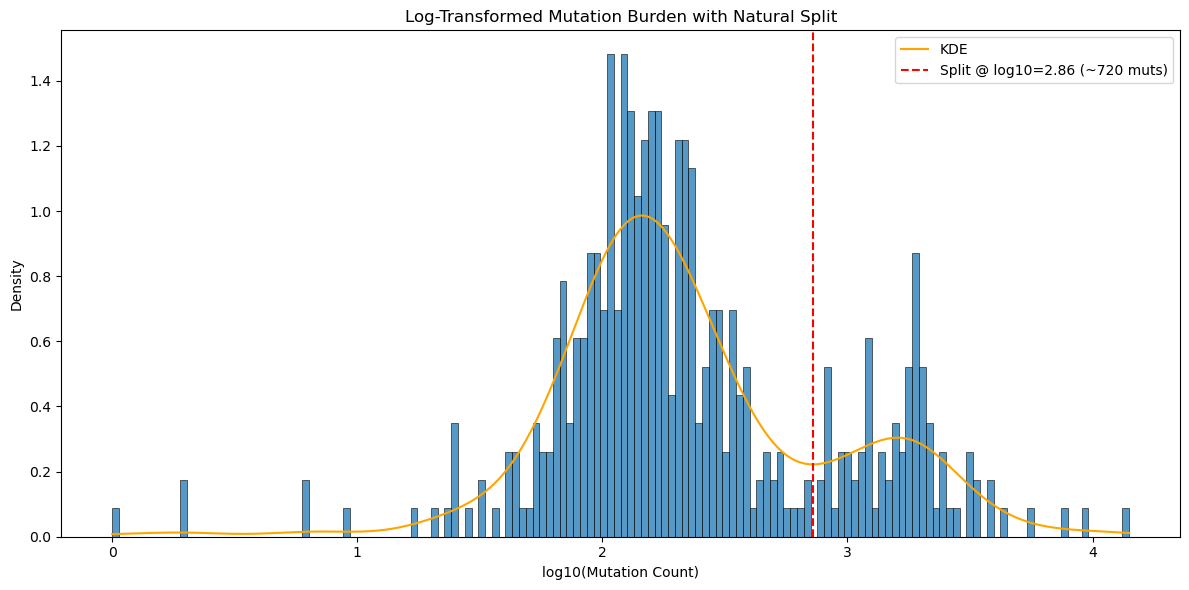

In [156]:
somatic_mut = read_somatic_mutations("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.mutations.txt")
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
counts_array = mutation_counts[mutation_counts > 0].values.astype(float)
log_counts = np.log10(counts_array)

kde = gaussian_kde(log_counts)
x_vals = np.linspace(log_counts.min(), log_counts.max(), 1000)
kde_vals = kde(x_vals)
mask = (x_vals > 1.5) & (x_vals < 3.5)
x_zoom = x_vals[mask]
kde_zoom = kde_vals[mask]

# Find trough (local minimum)
troughs, _ = find_peaks(-kde_zoom)
if len(troughs) > 0:
    log_split = x_zoom[troughs[0]]
    exact_split = 10**log_split
    print(f"Log10 split: {log_split:.3f}")
    print(f"Exact split: {exact_split:.0f} mutations")
else:
    log_split = None
    print("No trough found.")

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(log_counts, bins=150, kde=False, stat="density")
plt.plot(x_vals, kde_vals, color='orange', label='KDE')

# Plot vertical line for the split
if log_split:
    plt.axvline(log_split, color='red', linestyle='--', label=f"Split @ log10={log_split:.2f} (~{int(exact_split)} muts)")

plt.xlabel("log10(Mutation Count)")
plt.ylabel("Density")
plt.title("Log-Transformed Mutation Burden with Natural Split")
plt.legend()
plt.tight_layout()
plt.show()

In [157]:
hist_bins = np.histogram_bin_edges(log_counts, bins=50)
linear_bins = 10 ** hist_bins
bin_aligned_split = linear_bins[linear_bins < exact_split].max()
print(f"Adjusted split (previous bin edge): {bin_aligned_split:.0f} mutations")

Adjusted split (previous bin edge): 663 mutations


In [207]:
threshold = bin_aligned_split
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
mutation_split_df = mutation_counts.to_frame(name="mutation_count")

# Assign groups
mutation_split_df["mutation_group"] = mutation_split_df["mutation_count"].apply(
    lambda x: "High" if x >= threshold else "Low"
)

# Split into patient ID lists
low_patients = mutation_split_df[mutation_split_df["mutation_group"] == "Low"].index.tolist()
high_patients = mutation_split_df[mutation_split_df["mutation_group"] == "High"].index.tolist()

# Filter original mutation rows
low_mut = somatic_mut[somatic_mut['patient_id'].isin(low_patients)]
high_mut = somatic_mut[somatic_mut['patient_id'].isin(high_patients)]

In [208]:
expression = pd.read_csv("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.expression.txt", sep="\t")
expression.set_index(["patient_id"], inplace=True)
expression = expression.drop("sample_id", axis=1)
expression = expression.fillna(0)
metadata = pd.read_csv("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.metadata.txt", sep="\t")
metadata.set_index("patient_id", inplace=True)

In [437]:
metadata.OS.value_counts()

OS
0.0    255
1.0    160
Name: count, dtype: int64

In [209]:
metadata.shape

(415, 18)

In [440]:
metadata.columns

Index(['type', 'age_at_initial_pathologic_diagnosis', 'gender', 'race',
       'ajcc_pathologic_tumor_stage', 'histological_type',
       'histological_grade', 'tumor_status', 'vital_status', 'OS', 'OS.time',
       'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction'],
      dtype='object')

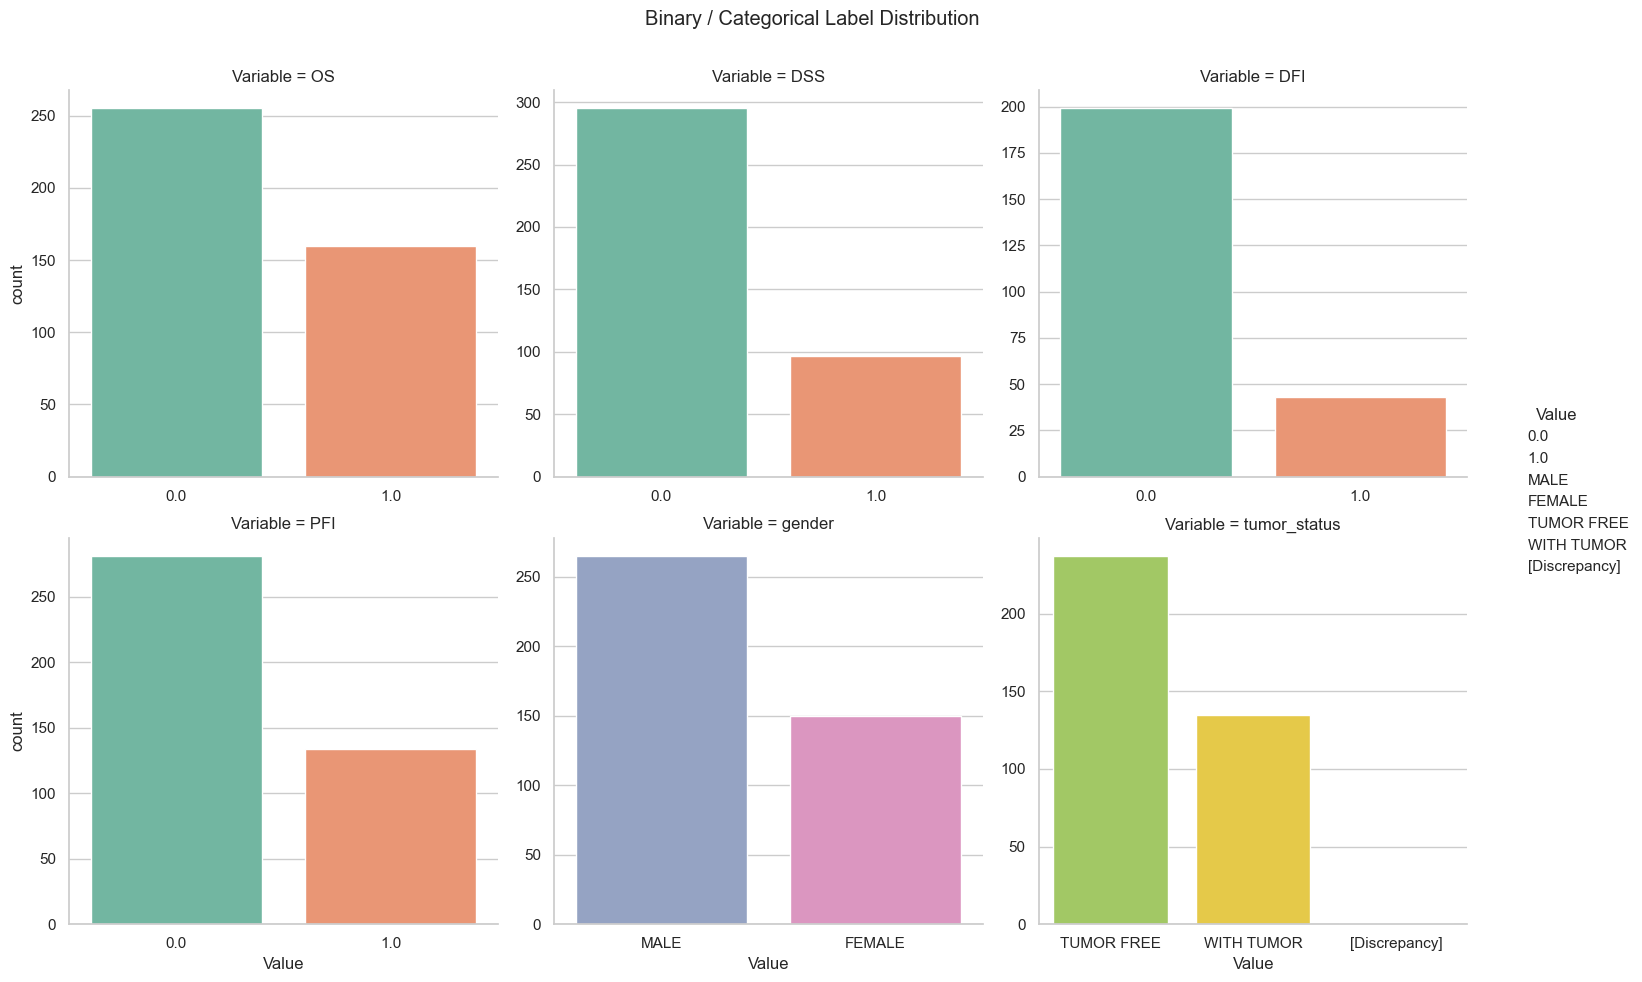

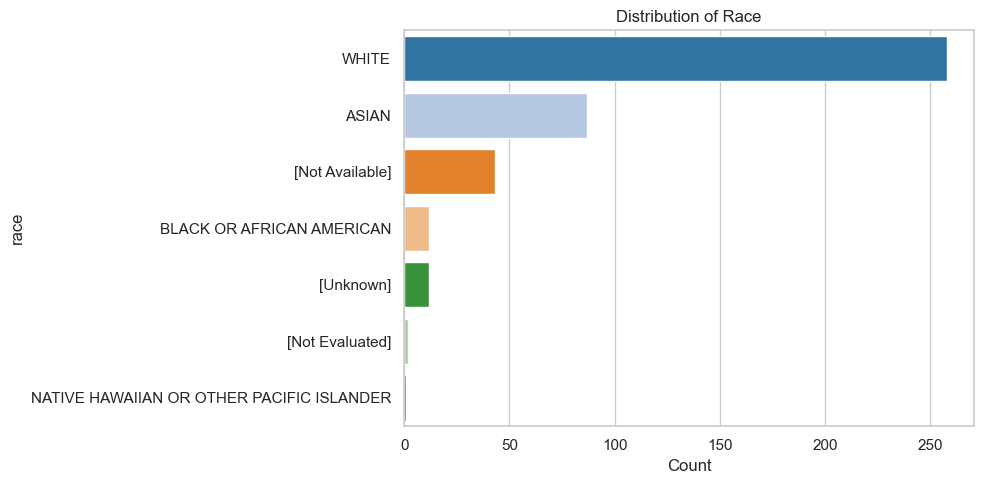

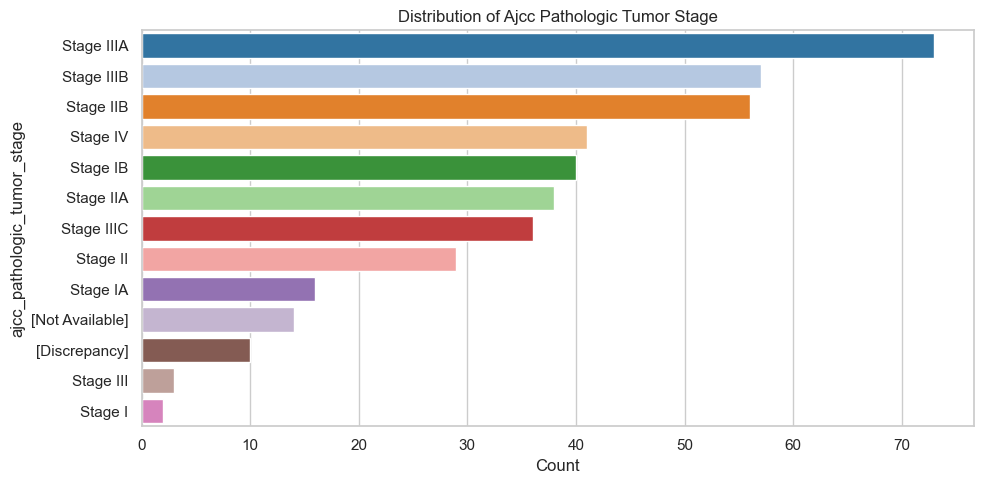

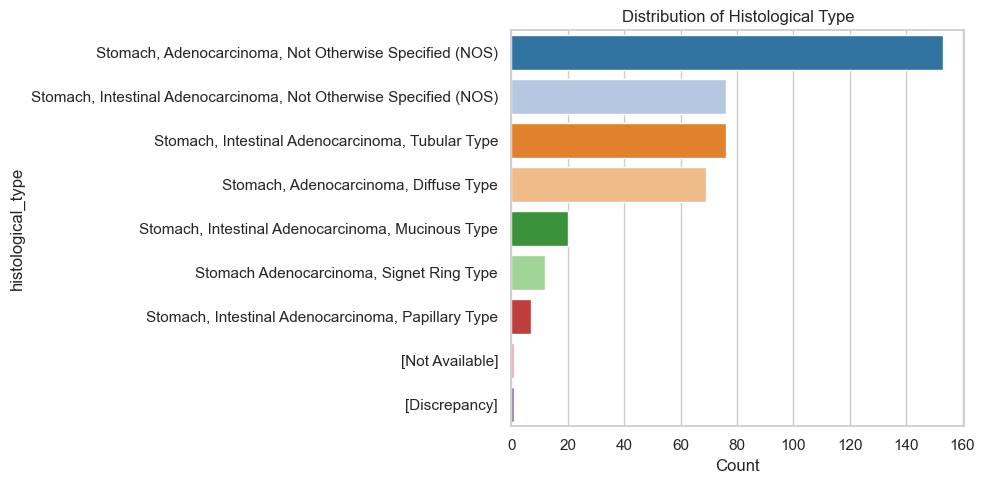

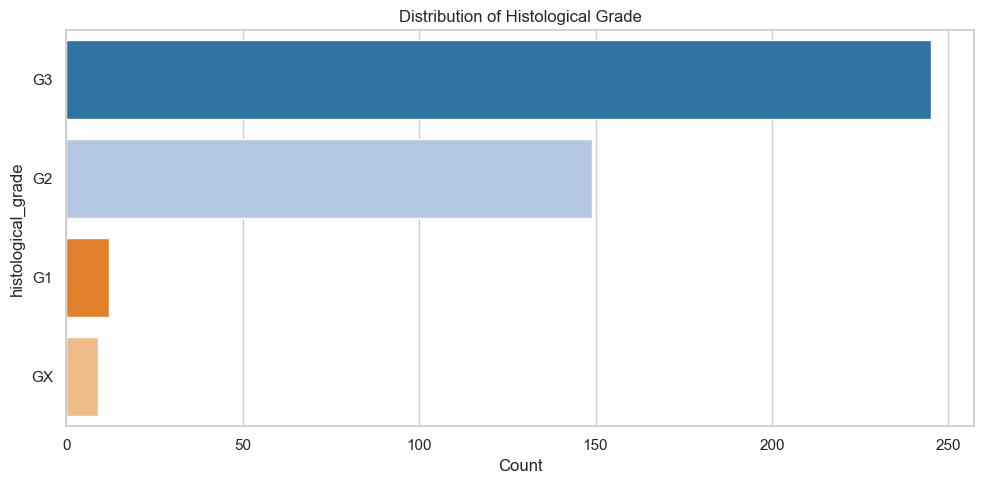

In [447]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

# ───────────────────────────────────────────────────
# 1. Binary Label Distribution – One Facet per Label
# ───────────────────────────────────────────────────
binary_vars = ['OS', 'DSS', 'DFI', 'PFI', 'gender', 'tumor_status']
binary_data = metadata[binary_vars].melt(var_name='Variable', value_name='Value')

g = sns.catplot(
    data=binary_data,
    x='Value', col='Variable',
    kind='count', col_wrap=3,
    palette='Set2',
    sharex=False, sharey=False
)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Binary / Categorical Label Distribution")
plt.show()

# ───────────────────────────────────────────────────
# 2. Categorical Annotations – Separate for Each
# ───────────────────────────────────────────────────
cat_vars = ['race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade']

for var in cat_vars:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=metadata, y=var, order=metadata[var].value_counts().index, palette='tab20')
    plt.title(f"Distribution of {var.replace('_', ' ').title()}")
    plt.xlabel("Count")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()


In [454]:
metadata['OS.time'].max() / 365

np.float64(10.191780821917808)

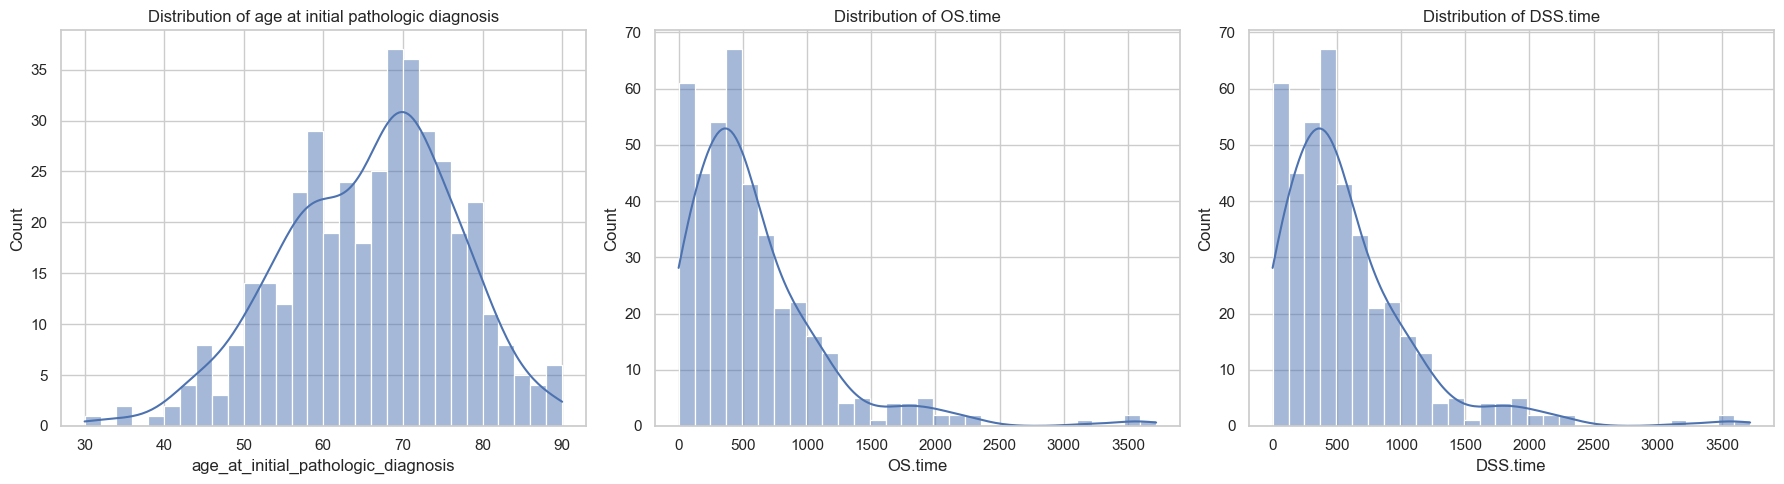

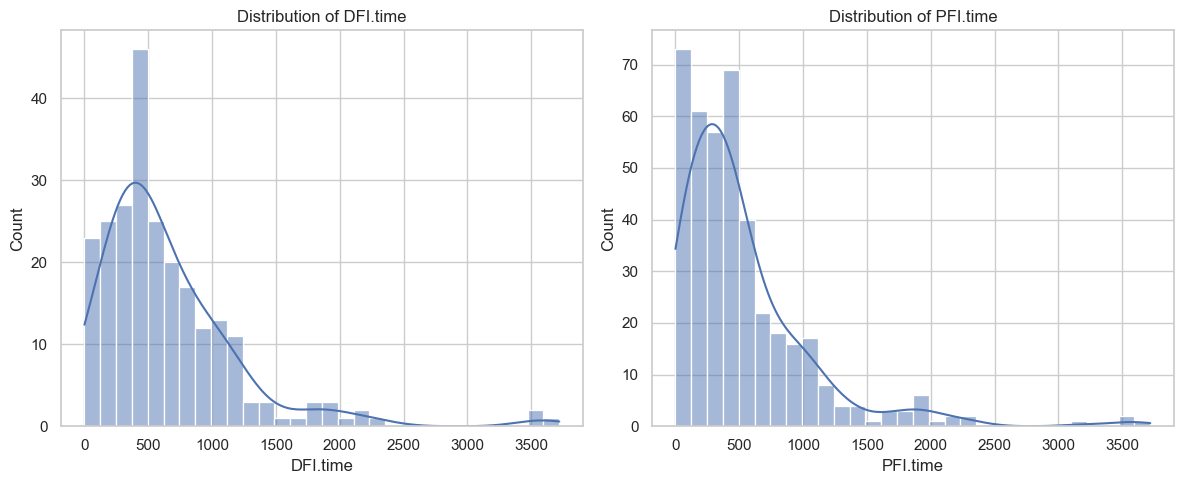

In [443]:
# ─────────────────────────────
# 3. Continuous Variable Histograms (Part 1)
# ─────────────────────────────
cont_vars_part1 = ['age_at_initial_pathologic_diagnosis', 'OS.time', 'DSS.time']
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
for i, var in enumerate(cont_vars_part1):
    sns.histplot(data=metadata, x=var, kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {var.replace('_', ' ')}")
plt.tight_layout()
plt.show()

# ─────────────────────────────
# 4. Continuous Variable Histograms (Part 2)
# ─────────────────────────────
cont_vars_part2 = ['DFI.time', 'PFI.time']
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
for i, var in enumerate(cont_vars_part2):
    sns.histplot(data=metadata, x=var, kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {var.replace('_', ' ')}")
plt.tight_layout()
plt.show()


# All DSS

(386, 3238)
(383, 3238)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 100}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.712911  0.421978  0.739130   0.400000  0.068966   
1  Logistic Regression  0.759423  0.558791  0.782609   0.625000  0.344828   
2                  SVM  0.760225  0.564309  0.808696   0.666667  0.482759   

         F1  
0  0.117647  
1  0.444444  
2  0.560000  


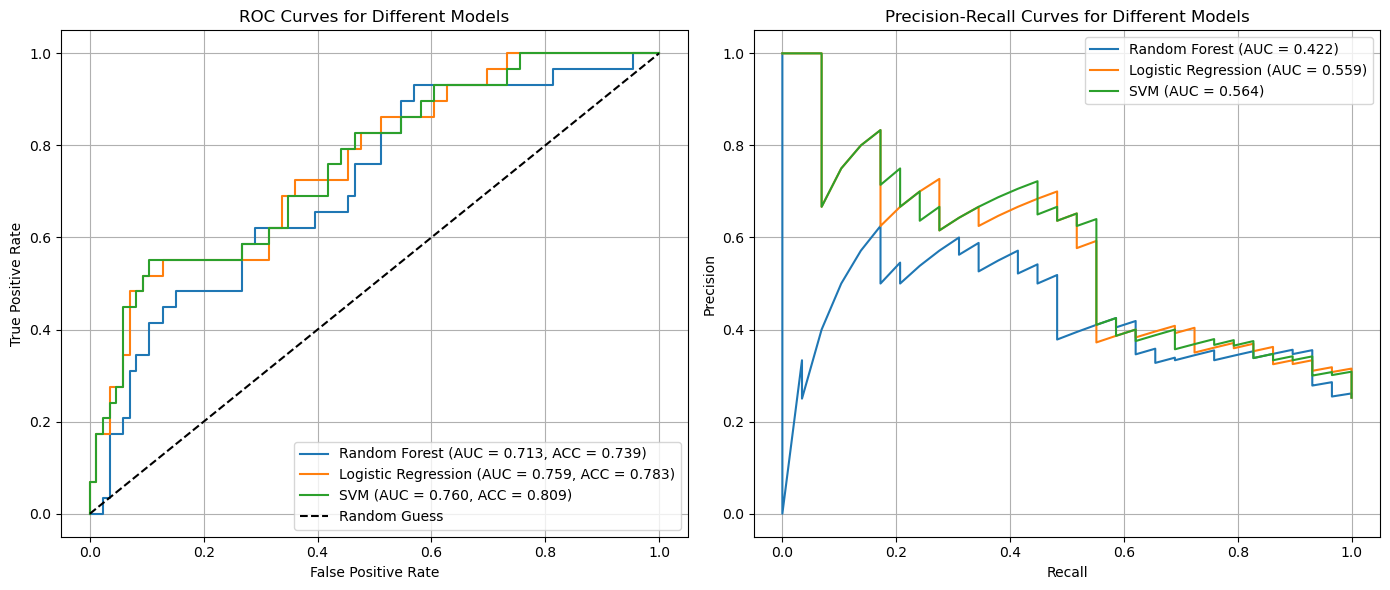

In [344]:
all_DSS_without_featureSelect_result = train_model(metadata, somatic_mut, expression, ['DSS', 'DSS.time'])

# All DFI

(240, 3169)
(238, 3169)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 3, 'n_estimators': 250}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.754889  0.380911  0.833333   0.600000  0.230769   
1  Logistic Regression  0.654498  0.389758  0.805556   0.444444  0.307692   
2                  SVM  0.664928  0.392508  0.791667   0.375000  0.230769   

         F1  
0  0.333333  
1  0.363636  
2  0.285714  


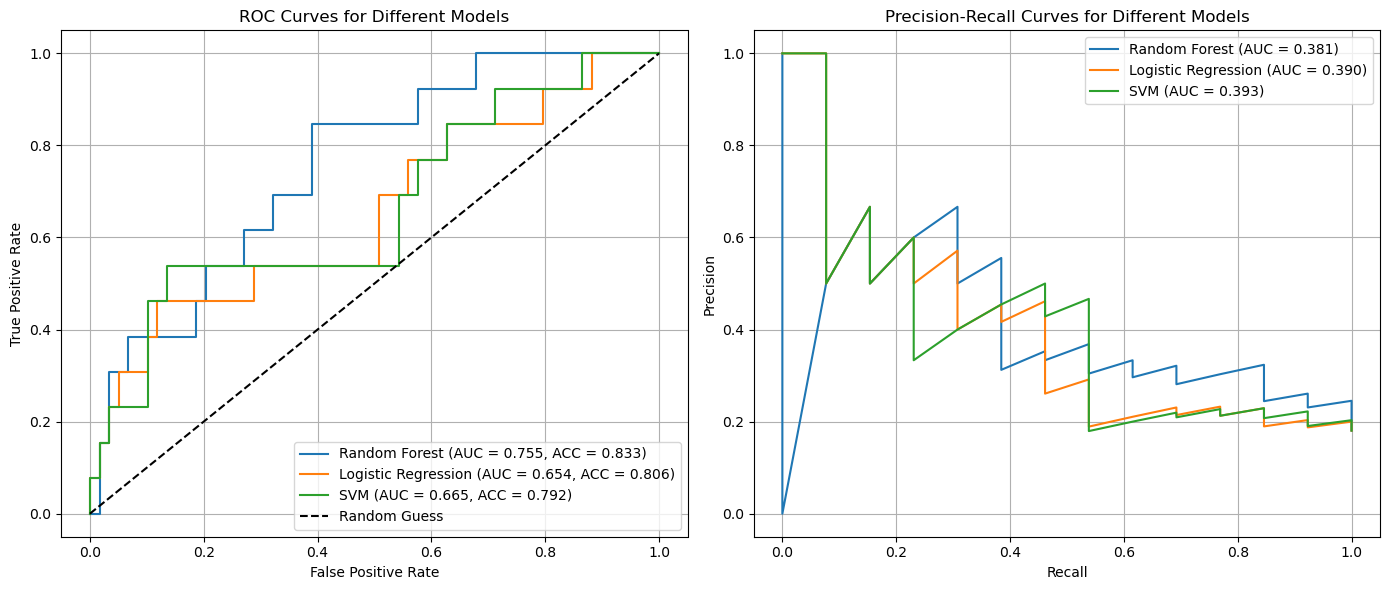

In [303]:
all_DFI_without_featureSelect_result = train_model(metadata, somatic_mut, expression, ['DFI', 'DFI.time'])

# All DFI loop different feature nums

In [323]:
all_DFI_result, all_DFI_best_models = train_model_with_featureSelection(metadata, somatic_mut, expression, ['DFI', 'DFI.time'], max_feature=200)
check_gene_expressions(all_DFI_result, expression, all_DFI_best_models)

Processing Feature Counts:   0%|                                                            | 0/2 [00:00<?, ?it/s]

Before drop nan: (240, 130)
Shape of X with 50 features: (238, 130)
Shape of y with 50 features: (238,)

Training Random Forest with 50 features...
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 150}

Training Logistic Regression with 50 features...


Processing Feature Counts:  50%|██████████████████████████                          | 1/2 [00:11<00:11, 11.76s/it]

Best parameters for Logistic Regression: {'C': 1.5, 'solver': 'lbfgs'}

Training SVM with 50 features...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}
Before drop nan: (240, 330)
Shape of X with 150 features: (238, 330)
Shape of y with 150 features: (238,)

Training Random Forest with 150 features...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 4, 'n_estimators': 250}

Training Logistic Regression with 150 features...


Processing Feature Counts: 100%|████████████████████████████████████████████████████| 2/2 [00:27<00:00, 13.63s/it]

Best parameters for Logistic Regression: {'C': 2, 'solver': 'newton-cg'}

Training SVM with 150 features...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Top 5 Most Important Features for SVM:
SVC(C=0.1, kernel='linear', probability=True, random_state=42)


In [324]:
# all_DFI_result.to_csv("All_DFI_results_without_featureSelect.csv", index=False)

# All OS

(409, 2764)
(406, 2764)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 4, 'n_estimators': 100}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'lbfgs'}

Training SVM...
Best parameters for SVM: {'C': 10, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.612482  0.554256  0.606557   0.486486  0.382979   
1  Logistic Regression  0.791773  0.700792  0.729508   0.694444  0.531915   
2                  SVM  0.773050  0.688200  0.737705   0.702703  0.553191   

         F1  
0  0.428571  
1  0.602410  
2  0.619048  


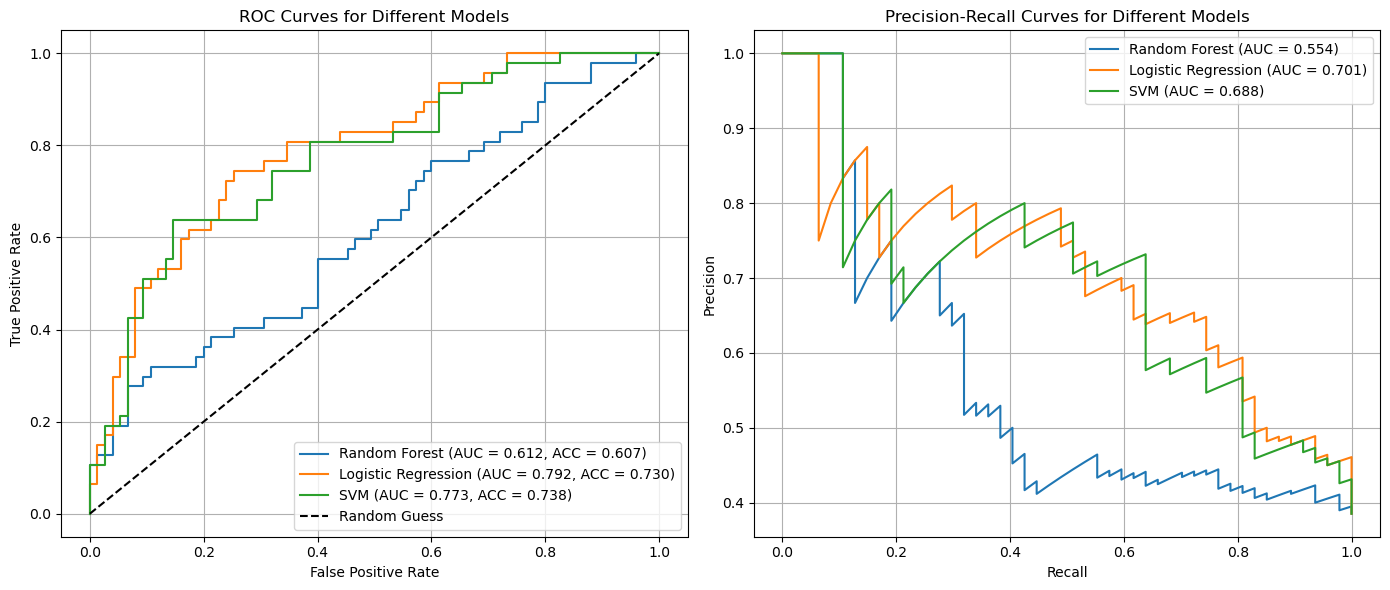

In [308]:
all_OS_without_featureSelect_result = train_model(metadata, somatic_mut, expression, ['OS', 'OS.time'])

# All OS 0.05

(409, 1471)
(406, 1471)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 3, 'min_samples_split': 4, 'n_estimators': 100}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'lbfgs'}

Training SVM...
Best parameters for SVM: {'C': 10, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.654184  0.505974  0.614754   0.500000  0.276596   
1  Logistic Regression  0.779007  0.685784  0.696721   0.638889  0.489362   
2                  SVM  0.777021  0.682286  0.737705   0.682927  0.595745   

         F1  
0  0.356164  
1  0.554217  
2  0.636364  


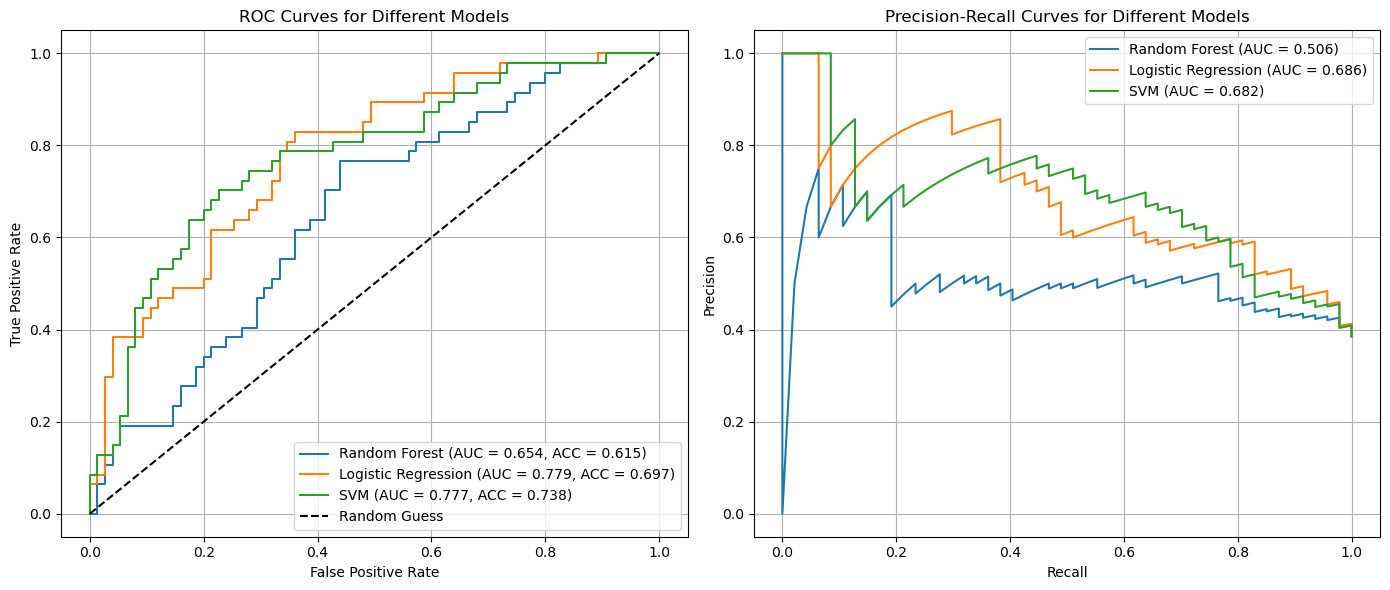

In [336]:
all_OS_without_featureSelect_result = train_model(metadata, somatic_mut, expression, ['OS', 'OS.time'], 0.05)

# All OS 0.01

(409, 359)
(406, 359)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 8, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.717447  0.587698  0.672131   0.612903  0.404255   
1  Logistic Regression  0.793191  0.743945  0.721311   0.622642  0.702128   
2                  SVM  0.777163  0.712516  0.704918   0.634146  0.553191   

         F1  
0  0.487179  
1  0.660000  
2  0.590909  


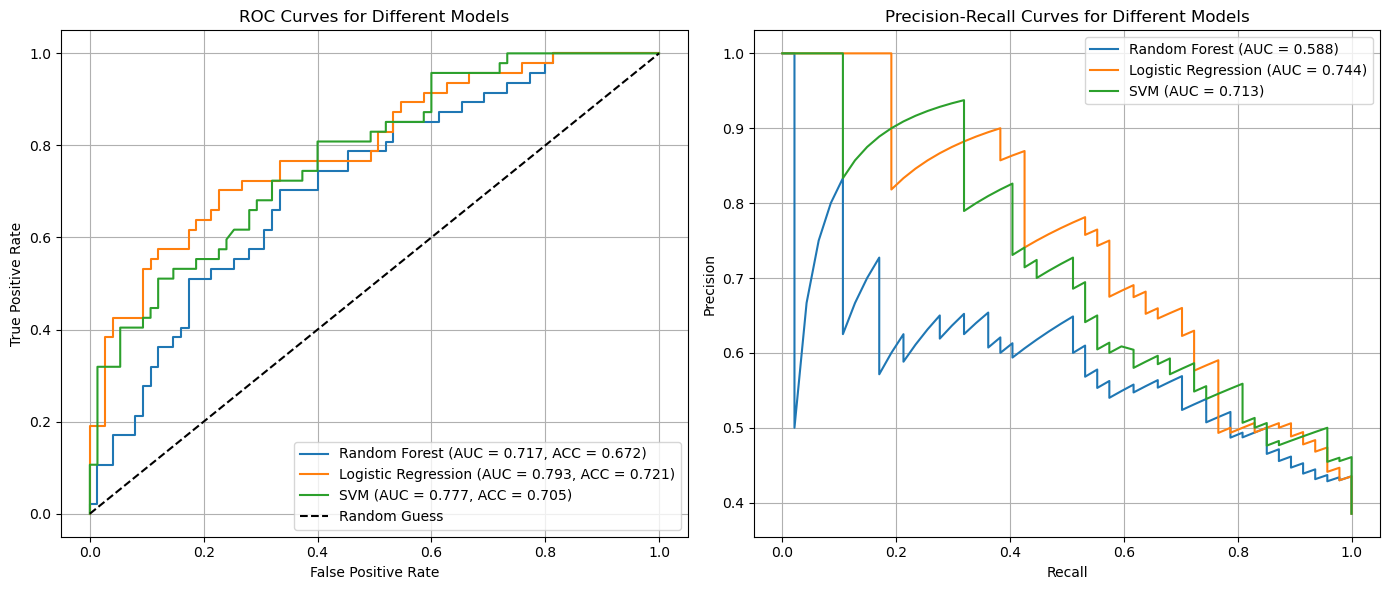

In [337]:
all_OS_without_featureSelect_result = train_model(metadata, somatic_mut, expression, ['OS', 'OS.time'], 0.01)

Processing Feature Counts:   0%|                                                            | 0/5 [00:00<?, ?it/s]

Before drop nan: (409, 84)
Shape of X with 50 features: (406, 84)
Shape of y with 50 features: (406,)

Training Random Forest with 50 features...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 4, 'n_estimators': 100}

Training Logistic Regression with 50 features...


/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

Best parameters for Logistic Regression: {'C': 0.5, 'solver': 'lbfgs'}

Training SVM with 50 features...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Training XGBoost with 50 features...


Processing Feature Counts:  20%|██████████▍                                         | 1/5 [00:23<01:32, 23.24s/it]

...

Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Before drop nan: (409, 384)
Shape of X with 350 features: (406, 384)
Shape of y with 350 features: (406,)

Training Random Forest with 350 features...
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 4, 'n_estimators': 150}

Training Logistic Regression with 350 features...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'lbfgs'}

Training SVM with 350 features...
Best parameters for SVM: {'C': 5, 'kernel': 'rbf'}

Training XGBoost with 350 features...


Processing Feature Counts:  80%|█████████████████████████████████████████▌          | 4/5 [02:58<00:50, 50.86s/it]

Best parameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 150, 'subsample': 1.0}
Before drop nan: (409, 484)
Shape of X with 450 features: (406, 484)
Shape of y with 450 features: (406,)

Training Random Forest with 450 features...
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Training Logistic Regression with 450 features...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'lbfgs'}

Training SVM with 450 features...
Best parameters for SVM: {'C': 8, 'kernel': 'rbf'}

Training XGBoost with 450 features...


Processing Feature Counts: 100%|████████████████████████████████████████████████████| 5/5 [04:20<00:00, 52.02s/it]

Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}


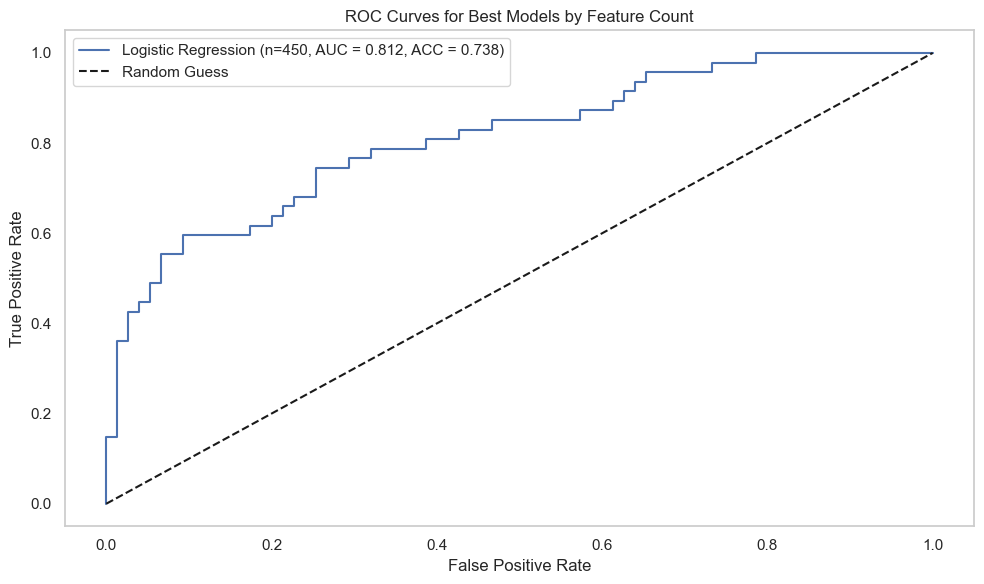

In [455]:
all_mut_OS_result, all_mut_OS_best_models = train_model_with_featureSelection(metadata, somatic_mut, expression, ['OS', 'OS.time'])




In [326]:
all_OS_result, all_OS_best_models = train_model_with_featureSelection(metadata, somatic_mut, expression, ['OS', 'OS.time'], max_feature=200)
check_gene_expressions(all_OS_result, expression, all_OS_best_models)

Processing Feature Counts:   0%|                                                            | 0/2 [00:00<?, ?it/s]

Before drop nan: (409, 134)
Shape of X with 50 features: (406, 134)
Shape of y with 50 features: (406,)

Training Random Forest with 50 features...
Best parameters for Random Forest: {'max_depth': 20, 'min_samples_split': 4, 'n_estimators': 200}

Training Logistic Regression with 50 features...


/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

Best parameters for Logistic Regression: {'C': 0.5, 'solver': 'liblinear'}

Training SVM with 50 features...


Processing Feature Counts:  50%|██████████████████████████                          | 1/2 [00:15<00:15, 15.82s/it]

Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}
Before drop nan: (409, 334)
Shape of X with 150 features: (406, 334)
Shape of y with 150 features: (406,)

Training Random Forest with 150 features...
Best parameters for Random Forest: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}

Training Logistic Regression with 150 features...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'lbfgs'}

Training SVM with 150 features...


Processing Feature Counts: 100%|████████████████████████████████████████████████████| 2/2 [00:36<00:00, 18.21s/it]

Best parameters for SVM: {'C': 8, 'kernel': 'rbf'}

Top 5 Most Important Features for SVM:
SVC(C=0.1, kernel='linear', probability=True, random_state=42)


# Low DFI

(141, 3210)
(141, 3210)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 3, 'min_samples_split': 4, 'n_estimators': 100}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 2, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.732026  0.344538  0.790698   0.500000  0.111111   
1  Logistic Regression  0.784314  0.565059  0.767442   0.428571  0.333333   
2                  SVM  0.771242  0.554971  0.767442   0.428571  0.333333   

         F1  
0  0.181818  
1  0.375000  
2  0.375000  


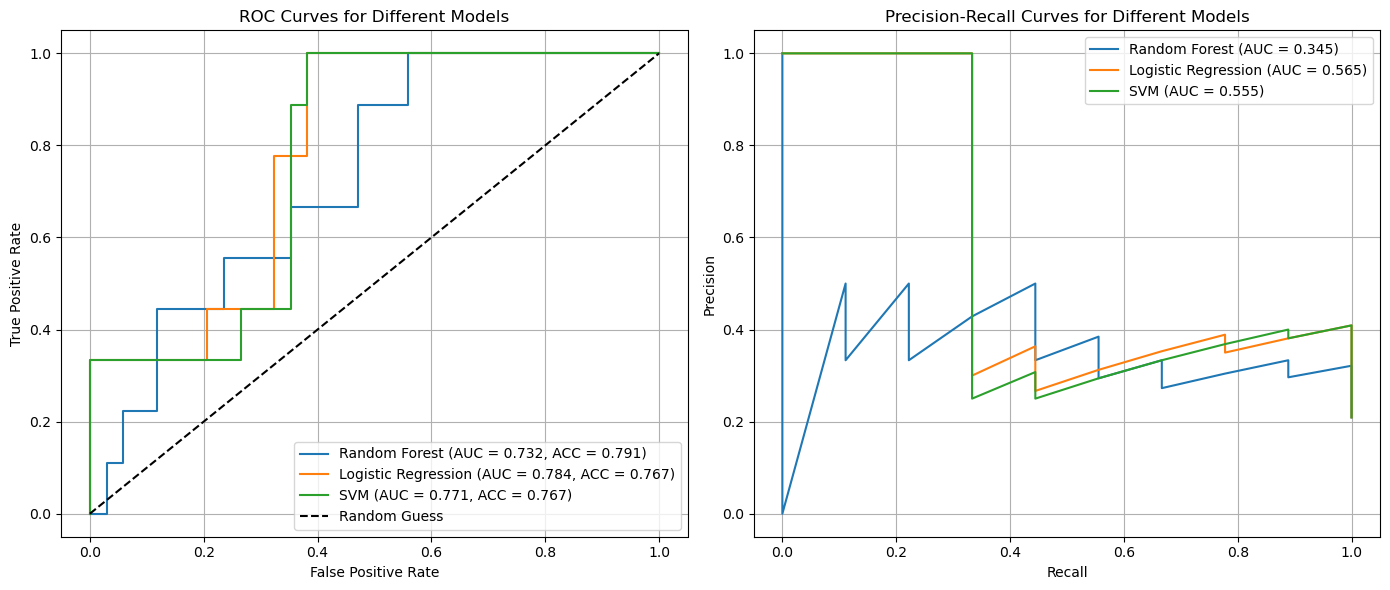

In [312]:
low_mut_metadata = metadata[metadata.index.isin(low_mut.patient_id)]
os_0 = low_mut_metadata[low_mut_metadata.OS == 0].sample(n=130, random_state=42)
os_1 = low_mut_metadata[low_mut_metadata.OS == 1].sample(n=130, random_state=42)
low_mut_metadata = pd.concat([os_0, os_1])

low_mut_DFI_without_featureSelect_result = train_model(low_mut_metadata, low_mut, expression, ['DFI', 'DFI.time'])

In [328]:
low_mut_DFI_result, low_mut_DFI_best_models = train_model_with_featureSelection(low_mut_metadata, low_mut, expression, ['DFI', 'DFI.time'], max_feature=800)
check_gene_expressions(low_mut_DFI_result, expression, low_mut_DFI_best_models)

Processing Feature Counts:   0%|                                                            | 0/8 [00:00<?, ?it/s]

Before drop nan: (141, 128)
Shape of X with 50 features: (141, 128)
Shape of y with 50 features: (141,)

Training Random Forest with 50 features...
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

Training Logistic Regression with 50 features...


Processing Feature Counts:  12%|██████▌                                             | 1/8 [00:10<01:16, 10.89s/it]

Best parameters for Logistic Regression: {'C': 2, 'solver': 'lbfgs'}

Training SVM with 50 features...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}
Before drop nan: (141, 328)
Shape of X with 150 features: (141, 328)
Shape of y with 150 features: (141,)

Training Random Forest with 150 features...
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}

Training Logistic Regression with 150 features...


Processing Feature Counts:  25%|█████████████                                       | 2/8 [00:22<01:07, 11.29s/it]

...

Best parameters for Logistic Regression: {'C': 0.5, 'solver': 'lbfgs'}

Training SVM with 550 features...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}
Before drop nan: (141, 1047)
Shape of X with 650 features: (141, 1047)
Shape of y with 650 features: (141,)

Training Random Forest with 650 features...
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 3, 'n_estimators': 250}

Training Logistic Regression with 650 features...
Best parameters for Logistic Regression: {'C': 1, 'solver': 'lbfgs'}

Training SVM with 650 features...


Processing Feature Counts:  88%|█████████████████████████████████████████████▌      | 7/8 [01:29<00:13, 13.56s/it]

Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}
Before drop nan: (141, 1147)
Shape of X with 750 features: (141, 1147)
Shape of y with 750 features: (141,)

Training Random Forest with 750 features...
Best parameters for Random Forest: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 250}

Training Logistic Regression with 750 features...
Best parameters for Logistic Regression: {'C': 1, 'solver': 'newton-cg'}

Training SVM with 750 features...


Processing Feature Counts: 100%|████████████████████████████████████████████████████| 8/8 [01:45<00:00, 13.14s/it]

Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Top 5 Most Important Features for SVM:
SVC(C=0.1, kernel='linear', probability=True, random_state=42)


# Low OS

(256, 1700)
(256, 1700)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 3, 'n_estimators': 300}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 4, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.695682  0.594085  0.675325   0.666667  0.684211   
1  Logistic Regression  0.874494  0.874109  0.805195   0.828571  0.763158   
2                  SVM  0.858974  0.874590  0.844156   0.882353  0.789474   

         F1  
0  0.675325  
1  0.794521  
2  0.833333  


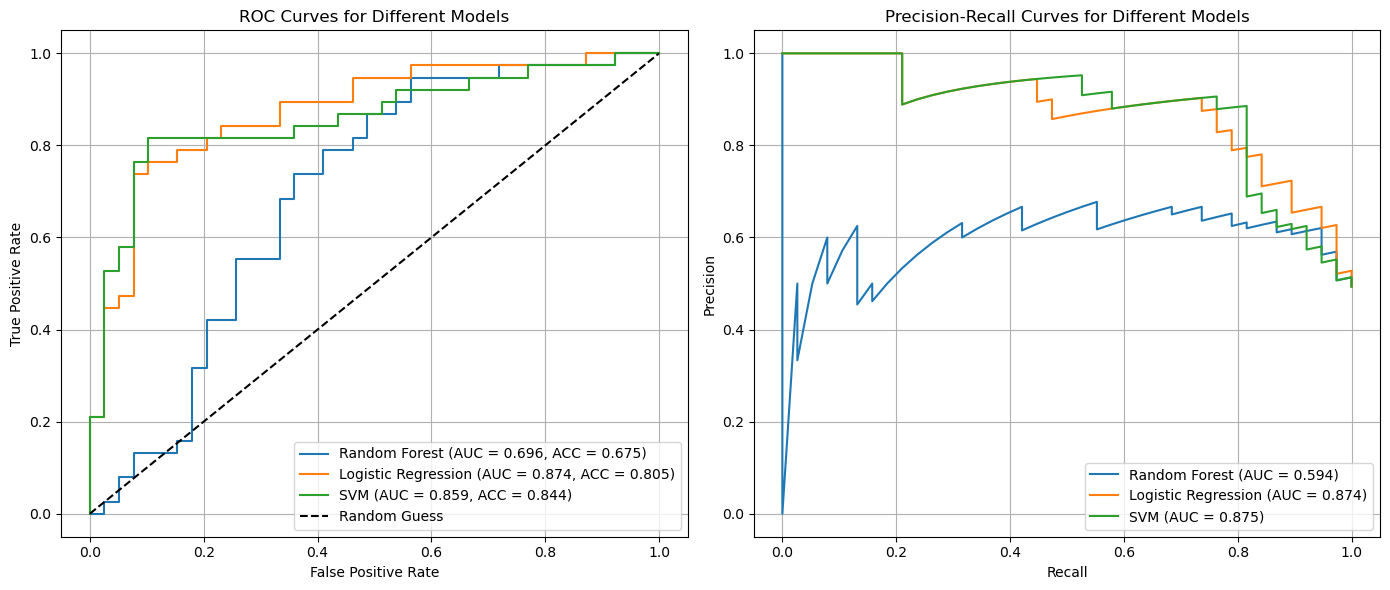

In [315]:
low_mut_metadata = metadata[metadata.index.isin(low_mut.patient_id)]
os_0 = low_mut_metadata[low_mut_metadata.OS == 0].sample(n=130, random_state=42)
os_1 = low_mut_metadata[low_mut_metadata.OS == 1].sample(n=130, random_state=42)
low_mut_metadata = pd.concat([os_0, os_1])

low_mut_OS_without_featureSelect_result = train_model(low_mut_metadata, low_mut, expression, ['OS', 'OS.time'])

In [456]:
def train_model_with_featureSelection(metadata, mutation, expression, endpoint_features, increment=100, max_feature=500):
    low_mut_metadata = metadata
    low_mut_patients = set(low_mut_metadata.index)
    low_mutation_matrix = pd.crosstab(
        index=mutation['patient_id'],
        columns=mutation['Hugo_Symbol'],
        values=1, 
        aggfunc='count'
    )
    low_mutation_matrix = low_mutation_matrix.fillna(0)
    low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
    low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

    low_metadata = low_mut_metadata.dropna(subset=endpoint_features)
    low_metadata['y'] = low_metadata[endpoint_features[0]]

    common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
    X_mut = low_mutation_matrix.loc[common_patients]
    X_exp = low_exp_matrix.loc[common_patients]
    X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                     'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                     'histological_grade', 'tumor_status']]

    # Step 3: Feature Selection
    # 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
    mutation_freq = X_mut.mean()
    selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
    X_mut_selected = X_mut[selected_mut_genes]

    # 3.2: Gene Expression Features - Standardize and filter low-variance genes
    scaler = StandardScaler()
    X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
    exp_variance = X_exp_scaled.var()
    selected_exp_genes = exp_variance[exp_variance > 0.01].index
    X_exp_selected = X_exp_scaled[selected_exp_genes]

    # 3.3: Clinical Features - Encode categorical variables
    categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
    numerical_cols = ['age_at_initial_pathologic_diagnosis']

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
            ('num', 'passthrough', numerical_cols)
        ])

    X_clinical_encoded = pd.DataFrame(
        preprocessor.fit_transform(X_clinical),
        index=X_clinical.index,
        columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
    )

    # 3.4: Univariate Feature Selection for Mutation and Expression Features
    y = low_metadata['y']

    mut_p_values = {}
    for col in X_mut_selected.columns:
        contingency_table = pd.crosstab(X_mut_selected[col], y)
        chi2, p, _, _ = chi2_contingency(contingency_table)
        mut_p_values[col] = p

    exp_p_values = {}
    for col in X_exp_selected.columns:
        group0 = X_exp_selected[col][y == 0]
        group1 = X_exp_selected[col][y == 1]
        t_stat, p = ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
        exp_p_values[col] = p

    feature_counts = list(range(50, max_feature + 1, increment))
    best_models = {}
    best_features = {'mut': {}, 'exp': {}}
    best_metrics = {'feature_count': [], 'Model': [], 'AUC-ROC': [], 'Accuracy': [], 'mut_features': [], 'exp_features': [], 'all_features': [], 'y': []}
    roc_data = {}  # Store ROC data for all models

    # Iterate over feature counts with progress bar
    for n_features in tqdm(feature_counts, desc="Processing Feature Counts"):
        selected_mut_features = sorted(mut_p_values.items(), key=lambda x: x[1])[:min(n_features//2, len(mut_p_values))]
        selected_mut_features = [col for col, p in selected_mut_features]
        selected_exp_features = sorted(exp_p_values.items(), key=lambda x: x[1])[:min(n_features//2, len(exp_p_values))]
        selected_exp_features = [col for col, p in selected_exp_features]

        X_mut_final = X_mut_selected[selected_mut_features]
        X_exp_final = X_exp_selected[selected_exp_features]
        X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
        X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)

        print("Before drop nan:", X.shape)
        X = X.dropna()
        print(f"Shape of X with {n_features} features: {X.shape}")
        y = low_metadata.loc[X.index, 'y']
        print(f"Shape of y with {n_features} features: {y.shape}")

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

        X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
        X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

        models = {
            'Random Forest': RandomForestClassifier(random_state=42),
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
            'SVM': SVC(probability=True, random_state=42),
            'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
        }
        param_grids = {
            'Random Forest': {
                'n_estimators': [100, 150, 200, 250, 300],
                'max_depth': [3, 5, 7, 10, 15, 20, None],
                'min_samples_split': [2, 3, 4, 5]
            },
            'Logistic Regression': {
                'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
                'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
            },
            'SVM': {
                'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
                'kernel': ['rbf', 'linear']
            },
            'XGBoost': {
                'n_estimators': [50, 100, 150, 200],
                'max_depth': [3, 5, 7, 10],
                'learning_rate': [0.01, 0.05, 0.1, 0.3],
                'subsample': [0.6, 0.8, 1.0]
            },
            'Gradient Boosting': {
                'n_estimators': [50, 100, 150, 200],
                'max_depth': [3, 5, 7, 10],
                'learning_rate': [0.01, 0.05, 0.1, 0.3],
                'subsample': [0.6, 0.8, 1.0]
            },
            'KNN': {
                'n_neighbors': [3, 5, 7, 9, 11],
                'weights': ['uniform', 'distance'],
                'metric': ['euclidean', 'manhattan']
            },
            'Decision Tree': {
                'max_depth': [3, 5, 7, 10, None],
                'min_samples_split': [2, 3, 4, 5],
                'min_samples_leaf': [1, 2, 3]
            }
        }

        # Train and evaluate each model
        for model_name, model in models.items():
            print(f"\nTraining {model_name} with {n_features} features...")
            grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
            grid_search.fit(X_train, y_train)

            best_model = grid_search.best_estimator_
            print(f"Best parameters for {model_name}:", grid_search.best_params_)

            y_pred = best_model.predict(X_test)
            y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)

            auc_roc = roc_auc_score(y_test, y_pred_proba)
            accuracy = accuracy_score(y_test, y_pred)

            if (n_features, model_name) not in best_models or auc_roc > max([m[2] for m in best_metrics.values() if m[0] == n_features and m[1] == model_name], default=0):
                best_models[(n_features, model_name)] = best_model
                best_features['mut'][(n_features, model_name)] = selected_mut_features
                best_features['exp'][(n_features, model_name)] = selected_exp_features
                best_metrics['feature_count'].append(n_features)
                best_metrics['Model'].append(model_name)
                best_metrics['AUC-ROC'].append(auc_roc)
                best_metrics['Accuracy'].append(accuracy)
                best_metrics['mut_features'].append(selected_mut_features)
                best_metrics['exp_features'].append(selected_exp_features)
                best_metrics['all_features'].append(X.columns.tolist())
                best_metrics['y'].append(y)

            # Compute and store ROC curve for this model
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            roc_data[(n_features, model_name)] = (fpr, tpr, auc_roc, accuracy)

        # Identify the best model for this feature count based on AUC-ROC
        current_roc_data = {k: v for k, v in roc_data.items() if k[0] == n_features}
        if current_roc_data:
            best_key = max(current_roc_data.items(), key=lambda x: x[1][2])[0]
            best_roc_data = {best_key: current_roc_data[best_key]}

    # Convert best_metrics to DataFrame
    best_metrics_df = pd.DataFrame(best_metrics)

    # Plot ROC Curves for the best model at each feature count
    plt.figure(figsize=(10, 6))
    for (n_features, model_name), (fpr, tpr, auc_roc, acc) in best_roc_data.items():
        plt.plot(fpr, tpr, label=f'{model_name} (n={n_features}, AUC = {auc_roc:.3f}, ACC = {acc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Best Models by Feature Count')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return best_metrics_df, best_models

Processing Feature Counts:   0%|                                                            | 0/5 [00:00<?, ?it/s]

Before drop nan: (256, 82)
Shape of X with 50 features: (256, 82)
Shape of y with 50 features: (256,)

Training Random Forest with 50 features...
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 250}

Training Logistic Regression with 50 features...


/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

Best parameters for Logistic Regression: {'C': 1.5, 'solver': 'lbfgs'}

Training SVM with 50 features...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Training XGBoost with 50 features...


Processing Feature Counts:  20%|██████████▍                                         | 1/5 [00:16<01:06, 16.74s/it]

...

Best parameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.6}
Before drop nan: (256, 382)
Shape of X with 350 features: (256, 382)
Shape of y with 350 features: (256,)

Training Random Forest with 350 features...
Best parameters for Random Forest: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 150}

Training Logistic Regression with 350 features...
Best parameters for Logistic Regression: {'C': 0.5, 'solver': 'newton-cg'}

Training SVM with 350 features...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Training XGBoost with 350 features...


Processing Feature Counts:  80%|█████████████████████████████████████████▌          | 4/5 [01:52<00:31, 31.47s/it]

Best parameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.6}
Before drop nan: (256, 482)
Shape of X with 450 features: (256, 482)
Shape of y with 450 features: (256,)

Training Random Forest with 450 features...
Best parameters for Random Forest: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 250}

Training Logistic Regression with 450 features...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'lbfgs'}

Training SVM with 450 features...
Best parameters for SVM: {'C': 10, 'kernel': 'rbf'}

Training XGBoost with 450 features...


Processing Feature Counts: 100%|████████████████████████████████████████████████████| 5/5 [02:40<00:00, 32.12s/it]

Best parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.6}


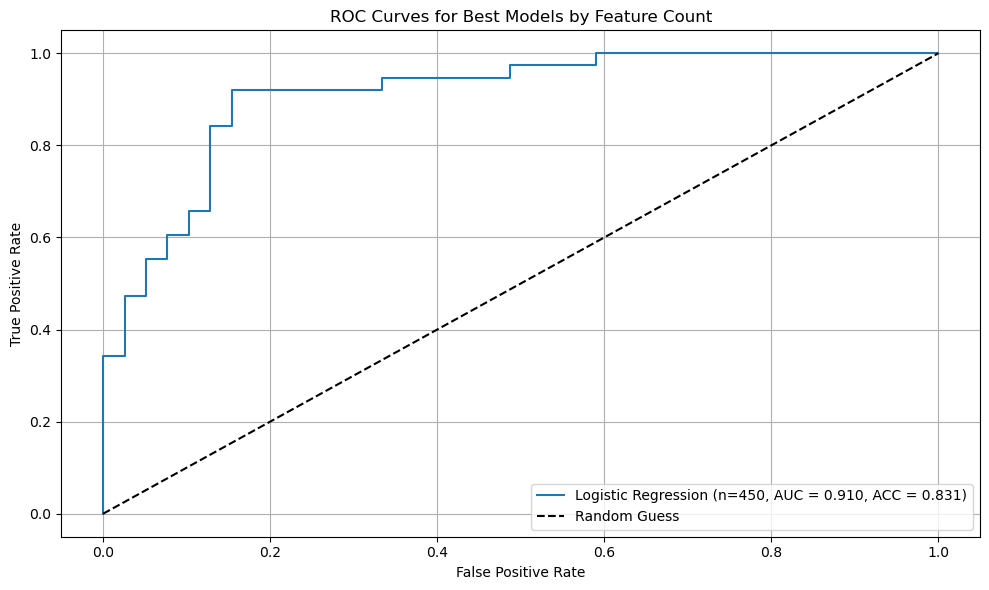

In [348]:
low_mut_OS_result, low_mut_OS_best_models = train_model_with_featureSelection(low_mut_metadata, low_mut, expression, ['OS', 'OS.time'])

# Low OS pvalue < 0.05

(256, 782)
(256, 782)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 150}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 8, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 8, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.701080  0.587491  0.675325   0.666667  0.684211   
1  Logistic Regression  0.885290  0.869361  0.831169   0.857143  0.789474   
2                  SVM  0.896761  0.860149  0.844156   0.842105  0.842105   

         F1  
0  0.675325  
1  0.821918  
2  0.842105  


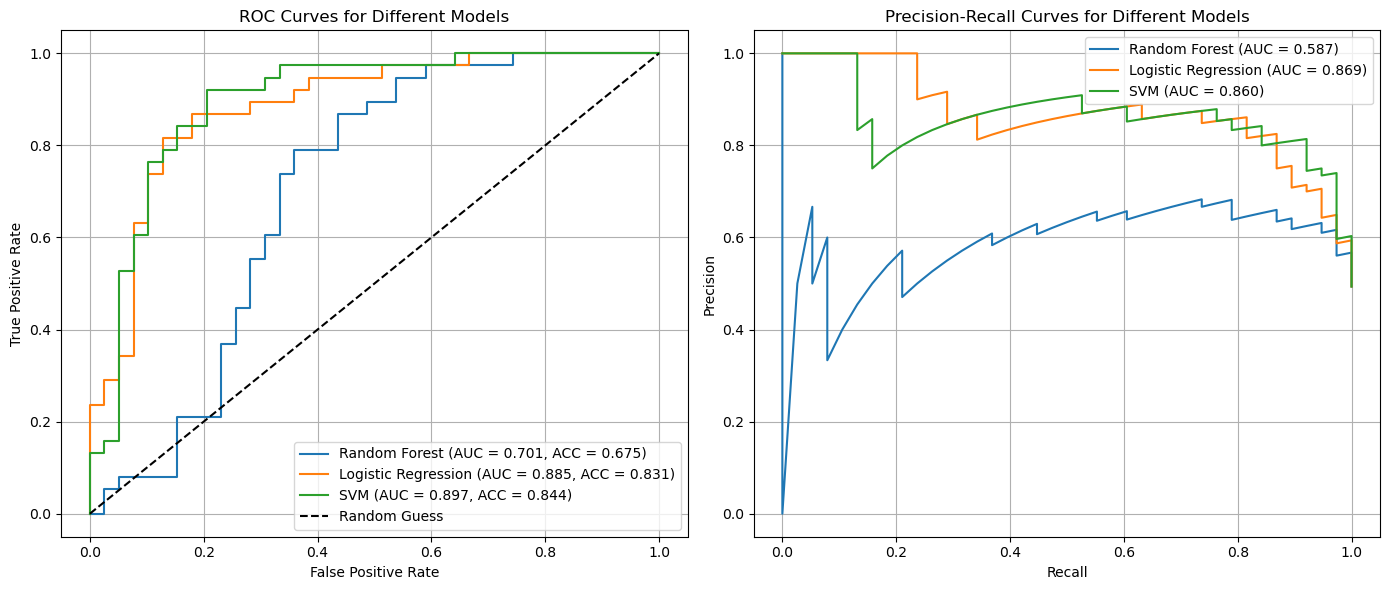

In [333]:
low_mut_metadata = metadata[metadata.index.isin(low_mut.patient_id)]
os_0 = low_mut_metadata[low_mut_metadata.OS == 0].sample(n=130, random_state=42)
os_1 = low_mut_metadata[low_mut_metadata.OS == 1].sample(n=130, random_state=42)
low_mut_metadata = pd.concat([os_0, os_1])

low_mut_OS_without_featureSelect_result = train_model(low_mut_metadata, low_mut, expression, ['OS', 'OS.time'], 0.05)

# Low OS pvalue < 0.01

(256, 138)
(256, 138)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 4, 'n_estimators': 150}

Training Logistic Regression...


/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}

Training SVM...
Best parameters for SVM: {'C': 10, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision    Recall  \
0        Random Forest  0.802969  0.762650  0.740260   0.704545  0.815789   
1  Logistic Regression  0.884615  0.869242  0.779221   0.838710  0.684211   
2                  SVM  0.849528  0.824968  0.753247   0.756757  0.736842   

         F1  
0  0.756098  
1  0.753623  
2  0.746667  


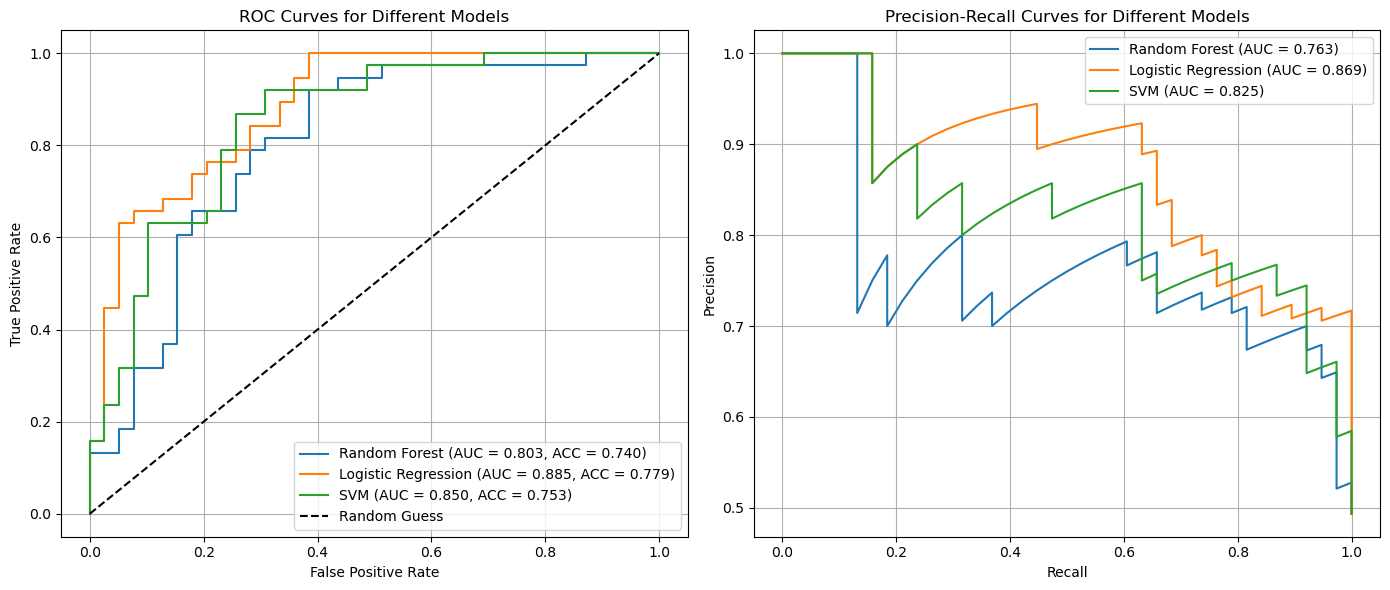

In [334]:
low_mut_metadata = metadata[metadata.index.isin(low_mut.patient_id)]
os_0 = low_mut_metadata[low_mut_metadata.OS == 0].sample(n=130, random_state=42)
os_1 = low_mut_metadata[low_mut_metadata.OS == 1].sample(n=130, random_state=42)
low_mut_metadata = pd.concat([os_0, os_1])

low_mut_OS_without_featureSelect_result = train_model(low_mut_metadata, low_mut, expression, ['OS', 'OS.time'], 0.01)

# High DFI

(53, 2747)
(52, 2747)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 3, 'min_samples_split': 4, 'n_estimators': 100}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision  Recall   F1
0        Random Forest  0.821429  0.613095     0.875        0.0     0.0  0.0
1  Logistic Regression  1.000000  1.000000     1.000        1.0     1.0  1.0
2                  SVM  1.000000  1.000000     0.875        0.0     0.0  0.0


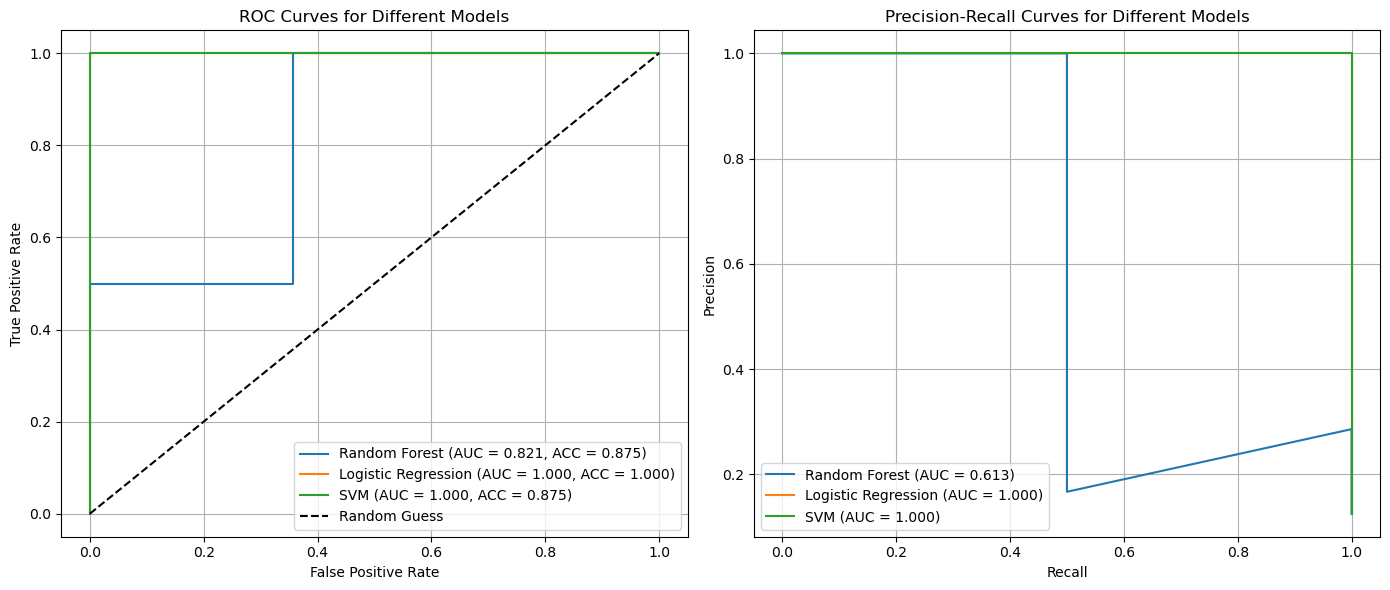

In [338]:
high_mut_metadata = metadata[metadata.index.isin(high_mut.patient_id)]
high_mut_DFI_without_featureSelect_result = train_model(high_mut_metadata, high_mut, expression, ['DFI', 'DFI.time'], 0.1)

# High OS

(85, 2800)
(84, 2800)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 200}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 1.5, 'solver': 'newton-cg'}

Training SVM...
Best parameters for SVM: {'C': 4, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Accuracy  Precision  Recall  \
0        Random Forest  0.680556  0.412141  0.653846   0.400000   0.250   
1  Logistic Regression  0.826389  0.802516  0.769231   0.625000   0.625   
2                  SVM  0.826389  0.790685  0.807692   0.714286   0.625   

         F1  
0  0.307692  
1  0.625000  
2  0.666667  


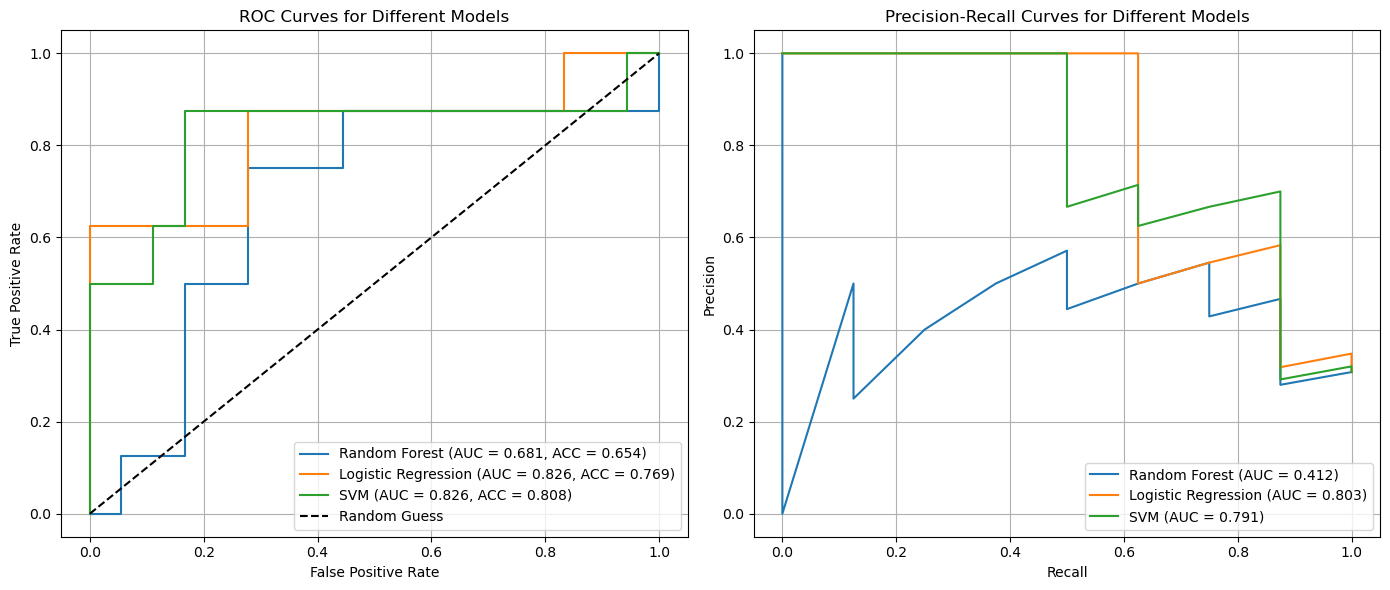

In [340]:
high_mut_metadata = metadata[metadata.index.isin(high_mut.patient_id)]
high_mut_DFI_without_featureSelect_result = train_model(high_mut_metadata, high_mut, expression, ['OS', 'OS.time'], 0.1)

Processing Feature Counts:   0%|                                                            | 0/5 [00:00<?, ?it/s]

Before drop nan: (85, 80)
Shape of X with 50 features: (84, 80)
Shape of y with 50 features: (84,)

Training Random Forest with 50 features...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 100}

Training Logistic Regression with 50 features...


/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}

Training SVM with 50 features...
Best parameters for SVM: {'C': 0.5, 'kernel': 'rbf'}

Training XGBoost with 50 features...


Processing Feature Counts:  20%|██████████▍                                         | 1/5 [00:12<00:51, 12.90s/it]

...

Best parameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.6}
Before drop nan: (85, 380)
Shape of X with 350 features: (84, 380)
Shape of y with 350 features: (84,)

Training Random Forest with 350 features...
Best parameters for Random Forest: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 250}

Training Logistic Regression with 350 features...
Best parameters for Logistic Regression: {'C': 2, 'solver': 'liblinear'}

Training SVM with 350 features...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Training XGBoost with 350 features...


Processing Feature Counts:  80%|█████████████████████████████████████████▌          | 4/5 [01:03<00:16, 16.87s/it]

Best parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.6}
Before drop nan: (85, 480)
Shape of X with 450 features: (84, 480)
Shape of y with 450 features: (84,)

Training Random Forest with 450 features...
Best parameters for Random Forest: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 300}

Training Logistic Regression with 450 features...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}

Training SVM with 450 features...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Training XGBoost with 450 features...


Processing Feature Counts: 100%|████████████████████████████████████████████████████| 5/5 [01:26<00:00, 17.22s/it]

Best parameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.6}


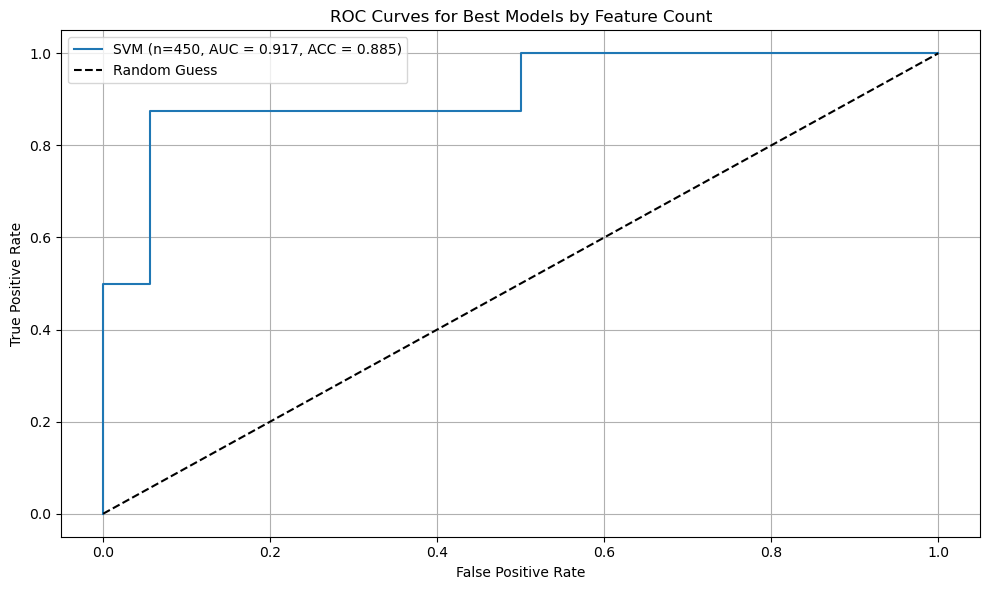

In [349]:
high_mut_OS_result, high_mut_OS_best_models = train_model_with_featureSelection(high_mut_metadata, high_mut, expression, ['OS', 'OS.time'])

# Significant genes

In [460]:
low_mut_OS_genes[:20]

['CXorf58',
 'MAVS',
 'SGSH',
 'NRP1',
 'DUSP16',
 'FLOT1',
 'LOC91450',
 'TCF20',
 'ANXA5',
 'DEPDC4',
 'RCAN1',
 'PCF11',
 'C22orf29',
 'SEC31A',
 'C19orf26',
 'RNF43',
 'ADM',
 'CDR2',
 'H2BFXP',
 'HR']

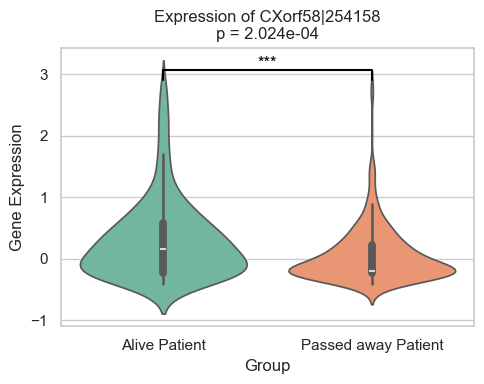

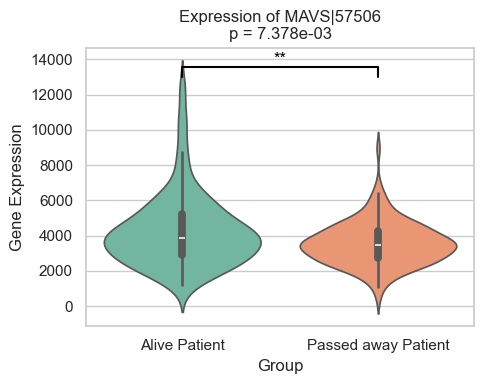

In [476]:
best_performance_result = low_mut_OS_result.sort_values("AUC-ROC", ascending=False).head(1)
y = best_performance_result.y.values[0]

genes = ['CXorf58|254158', 'MAVS|57506']

for gene_id in genes:
    # Subset to get expression values as Series (1D)
    alive = expression[expression.index.isin(y[y == 0].index)][gene_id].squeeze()
    dead = expression[expression.index.isin(y[y == 1].index)][gene_id].squeeze()

    # Prepare DataFrame for plotting
    plot_df = pd.DataFrame({
        'Gene Expression': pd.concat([alive, dead]),
        'Group': ['Alive Patient'] * len(alive) + ['Passed away Patient'] * len(dead)
    })

    # Perform Mann-Whitney U test
    stat, p_value = mannwhitneyu(alive, dead, alternative='two-sided')

    # Determine significance marker
    if p_value < 0.001:
        sig_marker = '***'
    elif p_value < 0.01:
        sig_marker = '**'
    elif p_value < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'ns'  # Not significant

    # Plot
    plt.figure(figsize=(5, 4))
    sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')

    # Add significance annotation
    # Get y-axis limits to place the annotation
    y_max = plot_df['Gene Expression'].max()
    y_range = plot_df['Gene Expression'].max() - plot_df['Gene Expression'].min()
    y_pos = y_max + y_range * 0.1  # Position slightly above the highest violin

    # Draw a line connecting the two groups
    x1, x2 = 0, 1  # x positions for 'Alive Patient' and 'Dead Patient'
    plt.plot([x1, x1, x2, x2], [y_pos - y_range * 0.05, y_pos, y_pos, y_pos - y_range * 0.05], lw=1.5, color='black')

    # Add the significance marker above the line
    plt.text((x1 + x2) / 2, y_pos, sig_marker, ha='center', va='bottom', color='black', fontsize=12)

    # Customize plot
    plt.title(f"Expression of {gene_id}\np = {p_value:.3e}")
    plt.tight_layout()
    plt.show()

In [477]:
high_mut_OS_genes[:4]

['RBBP7', 'RDH5', 'ILKAP', 'DOLPP1']

In [480]:
for gene in expression.columns:
    if "RDH5" in gene:
        print(gene)

RDH5|5959


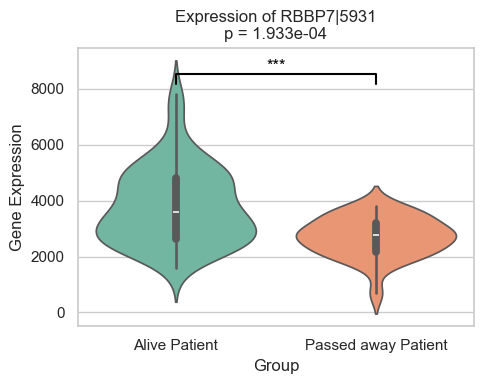

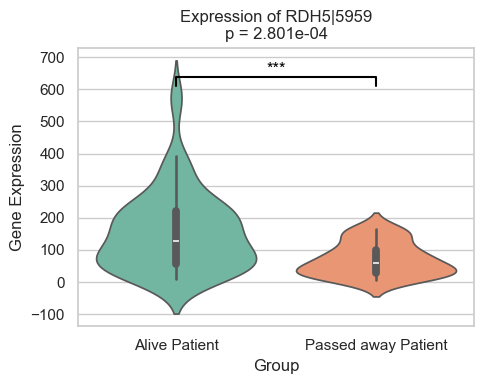

In [481]:
best_performance_result = high_mut_OS_result.sort_values("AUC-ROC", ascending=False).head(1)
y = best_performance_result.y.values[0]

genes = ['RBBP7|5931', 'RDH5|5959']

for gene_id in genes:
    # Subset to get expression values as Series (1D)
    alive = expression[expression.index.isin(y[y == 0].index)][gene_id].squeeze()
    dead = expression[expression.index.isin(y[y == 1].index)][gene_id].squeeze()

    # Prepare DataFrame for plotting
    plot_df = pd.DataFrame({
        'Gene Expression': pd.concat([alive, dead]),
        'Group': ['Alive Patient'] * len(alive) + ['Passed away Patient'] * len(dead)
    })

    # Perform Mann-Whitney U test
    stat, p_value = mannwhitneyu(alive, dead, alternative='two-sided')

    # Determine significance marker
    if p_value < 0.001:
        sig_marker = '***'
    elif p_value < 0.01:
        sig_marker = '**'
    elif p_value < 0.05:
        sig_marker = '*'
    else:
        sig_marker = 'ns'  # Not significant

    # Plot
    plt.figure(figsize=(5, 4))
    sns.violinplot(data=plot_df, x='Group', y='Gene Expression', palette='Set2')

    # Add significance annotation
    # Get y-axis limits to place the annotation
    y_max = plot_df['Gene Expression'].max()
    y_range = plot_df['Gene Expression'].max() - plot_df['Gene Expression'].min()
    y_pos = y_max + y_range * 0.1  # Position slightly above the highest violin

    # Draw a line connecting the two groups
    x1, x2 = 0, 1  # x positions for 'Alive Patient' and 'Dead Patient'
    plt.plot([x1, x1, x2, x2], [y_pos - y_range * 0.05, y_pos, y_pos, y_pos - y_range * 0.05], lw=1.5, color='black')

    # Add the significance marker above the line
    plt.text((x1 + x2) / 2, y_pos, sig_marker, ha='center', va='bottom', color='black', fontsize=12)

    # Customize plot
    plt.title(f"Expression of {gene_id}\np = {p_value:.3e}")
    plt.tight_layout()
    plt.show()

# GO term

In [393]:
low_mut_OS_genes = [gene.split("|")[0] for gene in low_mut_OS_result[
    (low_mut_OS_result.feature_count == 450) & 
    (low_mut_OS_result.Model == "Logistic Regression")
].exp_features.values[0]]

high_mut_OS_genes = [gene.split("|")[0] for gene in high_mut_OS_result[
    (high_mut_OS_result.feature_count == 450) & 
    (high_mut_OS_result.Model == "SVM")
].exp_features.values[0]]

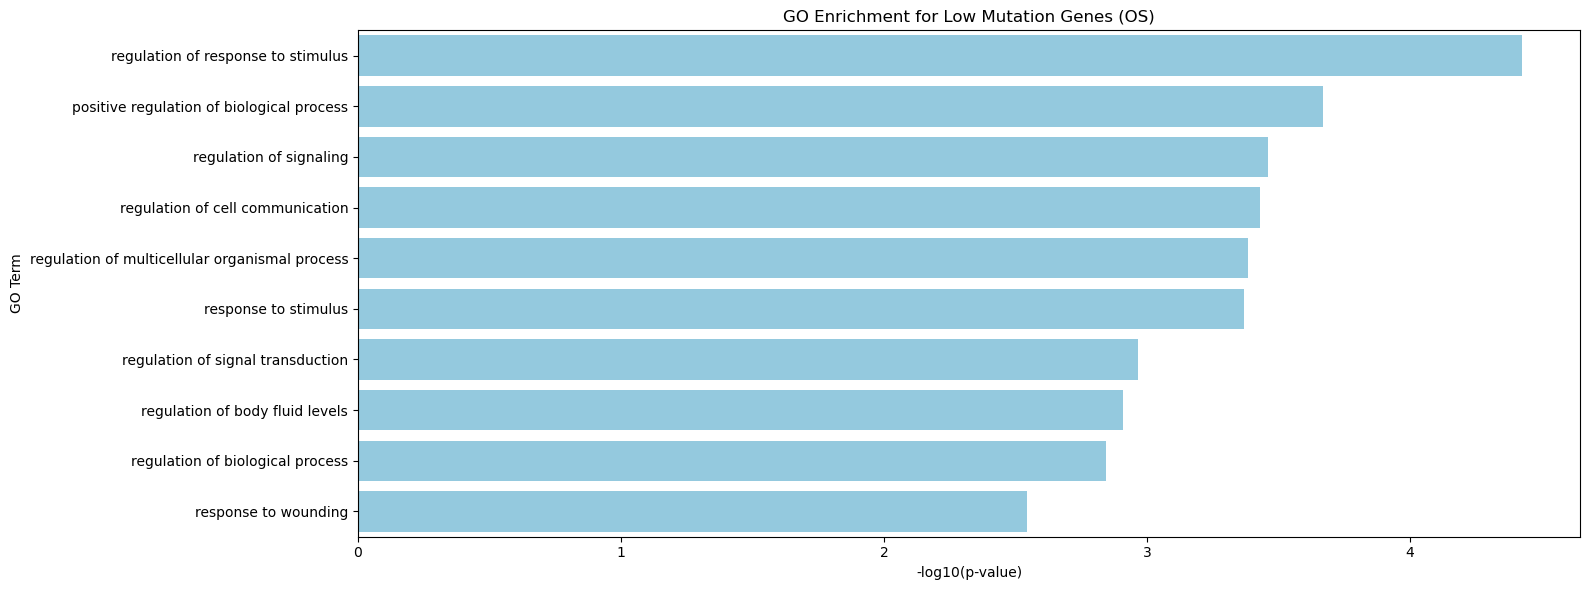

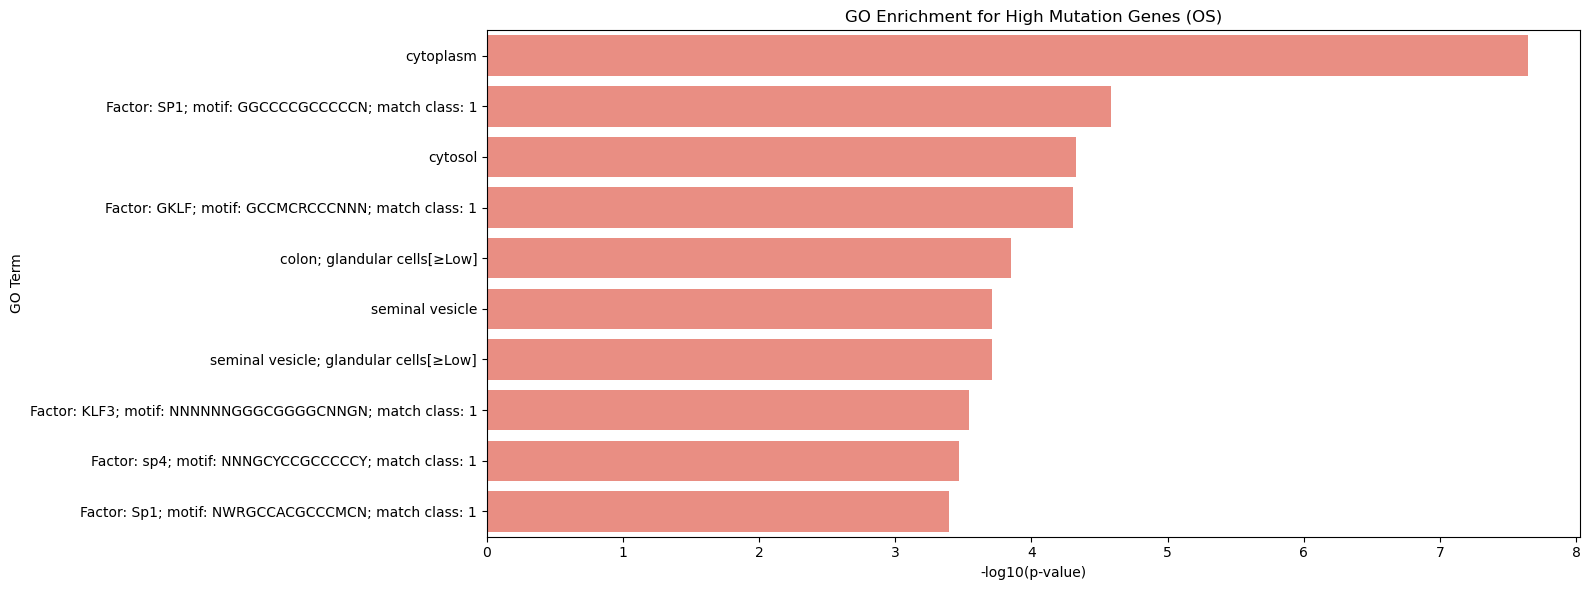

In [435]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

# Enrichment
low_results = gp.profile(organism='hsapiens', query=low_mut_OS_genes)
high_results = gp.profile(organism='hsapiens', query=high_mut_OS_genes)

# Filter GO:BP and add labels
low_results = low_results
high_results = high_results
low_results['Group'] = 'Low Mutation'
high_results['Group'] = 'High Mutation'

# Compute -log10(p)
low_results['-log10(p_value)'] = -np.log10(low_results['p_value'])
high_results['-log10(p_value)'] = -np.log10(high_results['p_value'])

# Top 15 terms
low_top = low_results[low_results.source == "GO:BP"].sort_values('p_value').head(10)
high_top = high_results.sort_values('p_value').head(10)

# Plot Low Mutation
plt.figure(figsize=(16, 6))
sns.barplot(data=low_top, x='-log10(p_value)', y='name', color='skyblue')
plt.title("GO Enrichment for Low Mutation Genes (OS)")
plt.xlabel("-log10(p-value)")
plt.ylabel("GO Term")
plt.tight_layout()
plt.show()

# Plot High Mutation
plt.figure(figsize=(16, 6))
sns.barplot(data=high_top, x='-log10(p_value)', y='name', color='salmon')
plt.title("GO Enrichment for High Mutation Genes (OS)")
plt.xlabel("-log10(p-value)")
plt.ylabel("GO Term")
plt.tight_layout()
plt.show()

In [457]:
high_results

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,Group,-log10(p_value)
0,GO:CC,GO:0005737,cytoplasm,2.258321e-08,True,"""The contents of a cell excluding the plasma m...",12394,184,145,22115,0.788043,0.011699,query_1,"[GO:0005622, GO:0110165]",High Mutation,7.646214
1,TF,TF:M12666_1,Factor: SP1; motif: GGCCCCGCCCCCN; match class: 1,2.604123e-05,True,Factor: SP1; motif: GGCCCCGCCCCCN; match class: 1,4530,190,78,20044,0.410526,0.017219,query_1,[TF:M12666],High Mutation,4.584338
2,GO:CC,GO:0005829,cytosol,4.717416e-05,True,"""The part of the cytoplasm that does not conta...",5513,184,78,22115,0.423913,0.014148,query_1,"[GO:0005737, GO:0110165]",High Mutation,4.326296
3,TF,TF:M01588_1,Factor: GKLF; motif: GCCMCRCCCNNN; match class: 1,4.918966e-05,True,Factor: GKLF; motif: GCCMCRCCCNNN; match class: 1,4076,190,72,20044,0.378947,0.017664,query_1,[TF:M01588],High Mutation,4.308126
4,HPA,HPA:0130051,colon; glandular cells[≥Low],1.414923e-04,True,colon; glandular cells[≥Low],6999,131,109,11019,0.832061,0.015574,query_1,[HPA:0130000],High Mutation,3.849267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,GO:CC,GO:0031982,vesicle,4.197970e-02,True,"""Any small, fluid-filled, spherical organelle ...",4012,184,54,22115,0.293478,0.013460,query_1,[GO:0043227],High Mutation,1.376961
96,TF,TF:M13135,Factor: SP4; motif: GGCCCCGCCCCCN,4.199504e-02,True,Factor: SP4; motif: GGCCCCGCCCCCN,5758,190,82,20044,0.431579,0.014241,query_1,[TF:M00000],High Mutation,1.376802
97,TF,TF:M12156_1,Factor: Sp2; motif: NTAAGYCCCGCCCMCTN; match c...,4.375607e-02,True,Factor: Sp2; motif: NTAAGYCCCGCCCMCTN; match c...,1029,190,25,20044,0.131579,0.024295,query_1,[TF:M12156],High Mutation,1.358962
98,HPA,HPA:0550052,stomach 2; glandular cells[≥Medium],4.437402e-02,True,stomach 2; glandular cells[≥Medium],6284,131,95,11019,0.725191,0.015118,query_1,[HPA:0550051],High Mutation,1.352871


In [431]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'browser'

gene_set = high_mut_OS_genes 
group_name = "High Mutation Genes"

# Or:
gene_set = low_mut_OS_genes
group_name = "Low Mutation Genes"

# Run GO enrichment
results = gp.profile(organism='hsapiens', query=gene_set)
results = results.sort_values('p_value')

go_terms = results['name'].tolist()
term_to_genes = results[['name', 'source']].set_index('name').to_dict()['source']


edges = []
for term in go_terms:
    for gene in term_to_genes[term]:
        edges.append((gene, term))

genes = list(set(g for g, _ in edges))
terms = list(set(t for _, t in edges))
nodes = genes + terms

source = [nodes.index(gene) for gene, _ in edges]
target = [nodes.index(term) for _, term in edges]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=10,
        thickness=15,
        line=dict(color="black", width=0.5),
        label=nodes,
        color=["lightblue"] * len(genes) + ["lightcoral"] * len(terms),
    ),
    link=dict(
        source=source,
        target=target,
        value=[1]*len(edges),
        color="rgba(150,150,150,0.4)"
    )
)])

fig.update_layout(title_text=f"Gene–GO Term: {group_name}", font_size=10)
fig.show()

In [430]:
results.source.value_counts()

source
HPA      48
TF       38
GO:CC    10
GO:MF     2
WP        1
HP        1
Name: count, dtype: int64